In [1]:
# ============================================================
# 问题2（第一小问）：跨季对比「排名法 vs 百分比法」表现，并判断是否更偏向观众投票
# 基于已保存到 ./data 的输出，重新读取需要用到的；不再依赖第一问内存变量
# ============================================================

import os
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0) 科研风格（优先 scienceplots，没有就用简洁风格）
# -----------------------------
try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "no-latex"])
except Exception:
    plt.rcParams.update({
        "figure.dpi": 160,
        "savefig.dpi": 300,
        "font.size": 11,
        "axes.titlesize": 12,
        "axes.labelsize": 11,
        "legend.fontsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "lines.linewidth": 1.6,
    })


In [2]:

DATA_DIR = "./data"
OUT_DIR = "./data"  # 结果继续落在同一个目录，便于后续问题2/3复用
os.makedirs(OUT_DIR, exist_ok=True)



In [3]:
# ============================================================
# 1) 读取第一问输出：票数估计（核心） + 周级淘汰真值（用于评估）
# ============================================================
path_votes = os.path.join("..", "t4", "data", "Q1_part1_pred_df_active_rows.csv")
path_evalw = os.path.join("..", "t4", "data", "Q1_part2_elimination_eval_week_df.csv")

df_votes = pd.read_csv(path_votes)
df_evalw = pd.read_csv(path_evalw)

# Compat: t4 output uses vote_share_hat
if "vote_share_hat" in df_votes.columns and "votes_hat" not in df_votes.columns:
    df_votes["votes_hat"] = df_votes["vote_share_hat"]

print("\n[Step 1] 读取完成：")
print("df_votes:", df_votes.shape, "columns:", df_votes.columns.tolist())
print("df_evalw:", df_evalw.shape, "columns:", df_evalw.columns.tolist())
print("\n[Step 1] df_votes head:")
df_votes.head()


[Step 1] 读取完成：
df_votes: (1773, 14) columns: ['season', 'week', 'celebrity_name', 'pair_id', 'judge_total', 'vote_share_hat', 'judge_rank', 'fan_rank', 'rank_total', 'judge_pct', 'combined_pct', 'elim_count', 'elim_flag', 'votes_hat']
df_evalw: (222, 6) columns: ['season', 'week', 'true_k', 'true_elims', 'actual_eliminated', 'actual_eliminated_next']

[Step 1] df_votes head:


,season,week,celebrity_name,pair_id,judge_total,vote_share_hat,judge_rank,fan_rank,rank_total,judge_pct,combined_pct,elim_count,elim_flag,votes_hat
0,1,3,Evander Holyfield,S1_Evander Holyfield __ Edyta Sliwinska,13.0,0.193301,5,3,8,0.122642,0.315943,1,False,0.193301
1,1,3,Joey McIntyre,S1_Joey McIntyre __ Ashly DelGrosso,22.0,0.220921,3,1,4,0.207547,0.428469,1,False,0.220921
2,1,3,John O'Hurley,S1_John O'Hurley __ Charlotte Jorgensen,24.0,0.185469,2,4,6,0.226415,0.411884,1,False,0.185469
3,1,3,Kelly Monaco,S1_Kelly Monaco __ Alec Mazo,21.0,0.214908,4,2,6,0.198113,0.413021,1,False,0.214908
4,1,3,Rachel Hunter,S1_Rachel Hunter __ Jonathan Roberts,26.0,0.185400,1,5,6,0.245283,0.430683,1,False,0.185400


In [4]:
'''
df_votes：每行是一个“赛季-周-选手”，里面有估计的 votes_hat 和 judge_total
df_evalw：每行是一个“赛季-周”，里面有真实淘汰者 true_eliminated

df_votes 用来跑两种规则算“预测淘汰者”

df_evalw 用来告诉我们“真实淘汰者是谁”，以便评估
”'''
df_evalw


,season,week,true_k,true_elims,actual_eliminated,actual_eliminated_next
0,1,3,1,Evander Holyfield,Trista Sutter,Evander Holyfield
1,1,4,1,Rachel Hunter,Evander Holyfield,Rachel Hunter
2,1,5,0,NaN,Rachel Hunter,NaN
3,2,2,1,Tatum O'Neal,Kenny Mayne,Tatum O'Neal
4,2,3,1,Giselle Fernandez,Tatum O'Neal,Giselle Fernandez
...,...,...,...,...,...,...
217,34,5,1,Scott Hoying,Hilaria Baldwin,Scott Hoying
218,34,7,1,Jen Affleck,Scott Hoying,Jen Affleck
219,34,8,1,Danielle Fishel,Jen Affleck,Danielle Fishel
220,34,9,1,Andy Richter,Danielle Fishel,Andy Richter


In [5]:
# 统一字段类型
df_votes["season"] = df_votes["season"].astype(int)
df_votes["week"] = df_votes["week"].astype(int)

# ============================================================
# 2) 解析 df_evalw 中的 true_eliminated 列（通常是字符串形式的 list）
# ============================================================
def parse_list_cell(x):
    """将字符串形式的 list 安全解析为 python list；解析失败则返回空list"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return []
    try:
        v = ast.literal_eval(s)
        if isinstance(v, list):
            return v
        return []
    except Exception:
        return []

# 兼容可能的列名：true_eliminated / pred_eliminated 等
if "true_eliminated" in df_evalw.columns:
    df_evalw["true_eliminated_list"] = df_evalw["true_eliminated"].apply(parse_list_cell)
else:
    df_evalw["true_eliminated_list"] = [[] for _ in range(len(df_evalw))]

df_evalw["season"] = df_evalw["season"].astype(int)
df_evalw["week"] = df_evalw["week"].astype(int)
df_evalw["true_k"] = df_evalw["true_eliminated_list"].apply(len)

print("\n[Step 2] true_k 分布：")
print(df_evalw["true_k"].value_counts().sort_index())


[Step 2] true_k 分布：
true_k
0    222
Name: count, dtype: int64


In [6]:
# 生成真值映射（season,week)->set
true_map = {
    (int(r.season), int(r.week)): set(r.true_eliminated_list)
    for r in df_evalw.itertuples(index=False)
}

In [7]:
true_map

{(1, 3): set(),
 (1, 4): set(),
 (1, 5): set(),
 (2, 2): set(),
 (2, 3): set(),
 (2, 4): set(),
 (2, 5): set(),
 (2, 6): set(),
 (2, 7): set(),
 (3, 2): set(),
 (3, 3): set(),
 (3, 4): set(),
 (3, 5): set(),
 (3, 6): set(),
 (3, 8): set(),
 (3, 9): set(),
 (4, 3): set(),
 (4, 4): set(),
 (4, 5): set(),
 (4, 6): set(),
 (4, 7): set(),
 (4, 8): set(),
 (4, 9): set(),
 (5, 5): set(),
 (5, 6): set(),
 (5, 7): set(),
 (5, 8): set(),
 (5, 9): set(),
 (6, 3): set(),
 (6, 4): set(),
 (6, 5): set(),
 (6, 6): set(),
 (6, 7): set(),
 (6, 8): set(),
 (6, 9): set(),
 (7, 2): set(),
 (7, 3): set(),
 (7, 5): set(),
 (7, 6): set(),
 (7, 7): set(),
 (7, 8): set(),
 (7, 9): set(),
 (8, 3): set(),
 (8, 4): set(),
 (8, 5): set(),
 (8, 6): set(),
 (8, 7): set(),
 (8, 8): set(),
 (8, 9): set(),
 (8, 10): set(),
 (9, 2): set(),
 (9, 3): set(),
 (9, 4): set(),
 (9, 5): set(),
 (9, 6): set(),
 (9, 7): set(),
 (9, 8): set(),
 (9, 9): set(),
 (10, 3): set(),
 (10, 4): set(),
 (10, 5): set(),
 (10, 6): set(),
 (1

In [8]:
# ============================================================
# 3) 定义两套规则：排名法 & 百分比法（对每季都强制跑两套）
#    - 输入：某个 season-week 的选手表（含 judge_total / votes_hat）
#    - 输出：pred_eliminated（集合，大小 = true_k；若 true_k=0 则空集合）
#    - 额外输出：combined 排名，以便做“偏向观众/评委”的度量
# ============================================================
def engine_rank_method(g: pd.DataFrame):
    """排名法：judge_rank + vote_rank 越大越差"""
    #     对同一周的所有选手：
    # 按评委总分排一次名：最高=第1名
    # 按观众票数排一次名：最高=第1名
    # 两个名次相加：combined_score = judge_rank + vote_rank
    # 相加结果越大越差，淘汰就是“最差的那几个
    gg = g.copy()

    # 名次：分/票越高越好，rank越小
    gg["judge_rank_w"] = gg["judge_total"].rank(ascending=False, method="min")
    gg["vote_rank_w"] = gg["votes_hat"].rank(ascending=False, method="min")

    # 合成排名：越大越差
    gg["combined_score"] = gg["judge_rank_w"] + gg["vote_rank_w"]

    # 合成名次：combined_score 越小越好
    gg["combined_rank"] = gg["combined_score"].rank(ascending=True, method="min")

    # 预排序：最差在前（便于取淘汰）
    gg = gg.sort_values(
        ["combined_score", "judge_total", "votes_hat"],
        ascending=[False, True, True]
    )
    return gg


def engine_percent_method(g: pd.DataFrame):
    """百分比法：judge_pct + vote_pct 越小越差"""
    # 对同一周的所有选手：
    # 每个人评委分除以当周评委分总和 → 得到 judge_pct
    # 每个人票数除以当周票数总和 → 得到 vote_pct
    # 合并：combined_score = judge_pct + vote_pct
    # 合并分越小越差，淘汰就是最低的那几个
    gg = g.copy()

    js = gg["judge_total"].sum()
    vs = gg["votes_hat"].sum()

    gg["judge_pct"] = gg["judge_total"] / js if js > 0 else 0.0
    gg["vote_pct"]  = gg["votes_hat"] / vs if vs > 0 else 0.0

    gg["combined_score"] = gg["judge_pct"] + gg["vote_pct"]  # 越大越好
    gg["combined_rank"]  = gg["combined_score"].rank(ascending=False, method="min")  # 越小越好

    gg = gg.sort_values(
        ["combined_score", "judge_total", "votes_hat"],
        ascending=[True, True, True]
    )
    return gg


def pick_eliminated(gg_sorted_worst_first: pd.DataFrame, k: int):
    """按最差顺序取前k名作为淘汰集合；k<=0 返回空集合"""
    #如果预测淘汰集合完全等于真实淘汰集合 → 1否则 → 0


    if k <= 0:
        return set()
    return set(gg_sorted_worst_first["celebrity_name"].head(k).tolist())


def spearman_approx_rankcorr(a: pd.Series, b: pd.Series):
    """Spearman近似：先取秩再Pearson（无 scipy 依赖）"""
    ra = a.rank(ascending=True, method="average")
    rb = b.rank(ascending=True, method="average")
    return ra.corr(rb, method="pearson")


In [9]:
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# 4) 对每个 season-week：同时运行两套方法，输出对照表
#    重点输出：
#    - 两方法预测淘汰者是否不同
#    - 各自与真值的一致性（若真值存在）
#    - “偏向观众”指标：combined_rank 与 vote_rank / judge_rank 哪个更接近
# ============================================================
needed_cols = ["season", "week", "celebrity_name", "judge_total", "votes_hat"]
for c in needed_cols:
    if c not in df_votes.columns:
        raise ValueError(f"df_votes 缺少必要字段：{c}")

grouped = df_votes.groupby(["season", "week"], sort=True)

rows = []
for (s, w), g in grouped:
    s = int(s); w = int(w)
    g = g.copy()

    # 真值淘汰集合
    true_set = true_map.get((s, w), set())
    k = len(true_set)

    # 如果该周没有淘汰（k=0），我们仍然记录两方法的综合排名差异（用于“偏向”分析）
    # 但淘汰一致率只在 k>0 的周上统计更合理
    # ----------------- 排名法 -----------------
    gg_rank = engine_rank_method(g)
    pred_rank_set = pick_eliminated(gg_rank, k)

    # ----------------- 百分比法 -----------------
    gg_pct = engine_percent_method(g)
    pred_pct_set = pick_eliminated(gg_pct, k)

    # ----------------- 两方法差异 -----------------
    diff_rank_vs_pct = int(pred_rank_set != pred_pct_set)

    # 与真值一致（仅 k>0 才有意义；k=0 视为一致）
    exact_rank = int((pred_rank_set == true_set) if k > 0 else True)
    exact_pct  = int((pred_pct_set == true_set)  if k > 0 else True)

    # ----------------- “偏向观众”度量 -----------------
    # 这里用周内“综合名次”与“观众名次/评委名次”的Spearman相关（绝对值越大越贴近）
    # 注意：placement/名次越小越好；vote_rank_w/judge_rank_w也是越小越好；
    # 因此直接比较 corr(combined_rank, vote_rank_w) 与 corr(combined_rank, judge_rank_w)
    # corr 更大（更接近 +1）表示更一致；也可用 abs(corr) 但这里一般是正相关

    # 每周我们都可以得到三种“排序”：
    # vote_rank_w：观众票数排名
    # judge_rank_w：评委分排名
    # combined_rank：合成规则算出来的最终排名
    # 如果 combined_rank 更像 vote_rank_w，说明它更偏向观众；反之更偏向评委。用 Spearman（秩相关）比较“像不像”  ,bias > 0：更贴近观众,bias < 0：更贴近评委


    
    # 排名法：
    corr_rank_vote  = spearman_approx_rankcorr(gg_rank["combined_rank"], gg_rank["vote_rank_w"])
    corr_rank_judge = spearman_approx_rankcorr(gg_rank["combined_rank"], gg_rank["judge_rank_w"])
    # 百分比法：需要先算 vote/judge 名次
    gg_pct["judge_rank_w"] = gg_pct["judge_total"].rank(ascending=False, method="min")
    gg_pct["vote_rank_w"]  = gg_pct["votes_hat"].rank(ascending=False, method="min")
    corr_pct_vote  = spearman_approx_rankcorr(gg_pct["combined_rank"], gg_pct["vote_rank_w"])
    corr_pct_judge = spearman_approx_rankcorr(gg_pct["combined_rank"], gg_pct["judge_rank_w"])

    # 倾向分数：>0 更贴近观众；<0 更贴近评委
    bias_rank = corr_rank_vote - corr_rank_judge
    bias_pct  = corr_pct_vote  - corr_pct_judge
    
    rows.append({
        "season": s,                     # 当前赛季编号（Season ID）
        "week": w,                       # 当前周次（Week Number）
        "n_active": int(len(g)),         # 本周仍在参赛的选手人数（Active contestants count）
        "true_k": int(k),                # 本周真实淘汰人数（Ground-truth eliminated count）
        "true_eliminated": sorted(list(true_set)),  # 本周真实被淘汰的选手名单（来自历史数据）
        "pred_rank_eliminated": sorted(list(pred_rank_set)),  # 使用【排名法】预测的淘汰选手名单
        "pred_pct_eliminated": sorted(list(pred_pct_set)),  
        # 使用【百分比法】预测的淘汰选手名单

        "rank_exact_match": int(exact_rank),  
        # 排名法是否完全命中真实淘汰结果（1=完全一致，0=不一致）

        "pct_exact_match": int(exact_pct),  
        # 百分比法是否完全命中真实淘汰结果（1=完全一致，0=不一致）

        "diff_rank_vs_pct_elim": int(diff_rank_vs_pct),  
        # 排名法与百分比法预测的淘汰结果是否不同（1=不同，0=相同）


        "corr_rank_combined_vs_voteRank": float(corr_rank_vote),  
        # 排名法下：综合排名 vs 观众投票排名 的秩相关系数
        # （越大说明综合结果越接近观众排序）

        "corr_rank_combined_vs_judgeRank": float(corr_rank_judge),  
        # 排名法下：综合排名 vs 评委评分排名 的秩相关系数
        # （越大说明综合结果越接近评委排序）

        "bias_rank_vote_minus_judge": float(bias_rank),  
        # 排名法的“偏观众程度”指标：
        # = corr(综合,观众) - corr(综合,评委)
        # >0 表示更偏向观众，<0 表示更偏向评委


        "corr_pct_combined_vs_voteRank": float(corr_pct_vote),  
        # 百分比法下：综合排名 vs 观众投票排名 的秩相关系数

        "corr_pct_combined_vs_judgeRank": float(corr_pct_judge),  
        # 百分比法下：综合排名 vs 评委评分排名 的秩相关系数

        "bias_pct_vote_minus_judge": float(bias_pct),  
        # 百分比法的“偏观众程度”指标：
        # = corr(综合,观众) - corr(综合,评委)
        # >0 表示更偏向观众，<0 表示更偏向评委

    })

q2_wk = pd.DataFrame(rows).sort_values(["season", "week"]).reset_index(drop=True)

print("\n[Step 4] q2_wk（周级对照表）构建完成：", q2_wk.shape)
q2_wk.head(10)


[Step 4] q2_wk（周级对照表）构建完成： (222, 16)


,season,week,n_active,true_k,true_eliminated,pred_rank_eliminated,pred_pct_eliminated,rank_exact_match,pct_exact_match,diff_rank_vs_pct_elim,corr_rank_combined_vs_voteRank,corr_rank_combined_vs_judgeRank,bias_rank_vote_minus_judge,corr_pct_combined_vs_voteRank,corr_pct_combined_vs_judgeRank,bias_pct_vote_minus_judge
0,1,3,5,0,[],[],[],1,1,0,0.447214,0.447214,0.000000,-0.100000,0.700000,-0.800000
1,1,4,4,0,[],[],[],1,1,0,0.774597,0.774597,0.000000,0.400000,0.800000,-0.400000
2,1,5,3,0,[],[],[],1,1,0,0.500000,0.500000,0.000000,0.500000,0.500000,0.000000
3,2,2,9,0,[],[],[],1,1,0,0.840366,0.831231,0.009135,0.816667,0.845196,-0.028529
4,2,3,8,0,[],[],[],1,1,0,0.400066,0.680994,-0.280928,0.404762,0.614502,-0.209741
5,2,4,7,0,[],[],[],1,1,0,0.309142,0.293590,0.015552,0.607143,-0.126131,0.733274
6,2,5,6,0,[],[],[],1,1,0,0.550782,0.376851,0.173931,0.828571,-0.142857,0.971429
7,2,6,5,0,[],[],[],1,1,0,0.288675,0.000000,0.288675,1.000000,-0.948683,1.948683
8,2,7,4,0,[],[],[],1,1,0,0.316228,0.500000,-0.183772,1.000000,-0.632456,1.632456
9,3,2,10,0,[],[],[],1,1,0,0.562715,0.307459,0.255255,0.842424,-0.289265,1.131689


In [10]:
# ============================================================
# 5) 汇总到赛季级：两方法表现对比 + 偏向观众指标
# ============================================================
# 仅在有淘汰的周（true_k>0）统计淘汰一致率更公平
mask_elim = q2_wk["true_k"] > 0

season_agg = (
    q2_wk.groupby("season", as_index=False)
    .apply(lambda x: pd.Series({
        "weeks": int(len(x)),
        "elim_weeks": int((x["true_k"] > 0).sum()),
        "rank_exact_elim": x.loc[x["true_k"] > 0, "rank_exact_match"].mean() if (x["true_k"] > 0).any() else np.nan,
        "pct_exact_elim":  x.loc[x["true_k"] > 0, "pct_exact_match"].mean()  if (x["true_k"] > 0).any() else np.nan,
        "diff_rate_elim":  x.loc[x["true_k"] > 0, "diff_rank_vs_pct_elim"].mean() if (x["true_k"] > 0).any() else np.nan,

        # 偏向观众：周内 bias 的均值（>0 偏观众，<0 偏评委）
        "bias_rank_mean": x["bias_rank_vote_minus_judge"].mean(),
        "bias_pct_mean":  x["bias_pct_vote_minus_judge"].mean(),

        # 更直观：综合名次更贴近观众 or 评委 的“胜率”
        "rank_vote_closer_rate": (x["bias_rank_vote_minus_judge"] > 0).mean(),
        "pct_vote_closer_rate":  (x["bias_pct_vote_minus_judge"] > 0).mean(),
    }))
    .reset_index(drop=True)
    .sort_values("season")
)

print("\n[Step 5] 赛季级汇总 season_agg：", season_agg.shape)
season_agg.head(10)


[Step 5] 赛季级汇总 season_agg： (34, 10)


,season,weeks,elim_weeks,rank_exact_elim,pct_exact_elim,diff_rate_elim,bias_rank_mean,bias_pct_mean,rank_vote_closer_rate,pct_vote_closer_rate
0,1,3.0,0.0,NaN,NaN,NaN,0.000000,-0.400000,0.000000,0.000000
1,2,6.0,0.0,NaN,NaN,NaN,0.003765,0.841262,0.666667,0.666667
2,3,7.0,0.0,NaN,NaN,NaN,0.129710,0.258987,0.714286,0.428571
3,4,7.0,0.0,NaN,NaN,NaN,-0.053655,0.124333,0.285714,0.571429
4,5,5.0,0.0,NaN,NaN,NaN,-0.019067,-0.079563,0.400000,0.600000
5,6,7.0,0.0,NaN,NaN,NaN,0.046086,0.114579,0.714286,0.714286
6,7,7.0,0.0,NaN,NaN,NaN,-0.011146,0.281177,0.285714,0.714286
7,8,8.0,0.0,NaN,NaN,NaN,-0.023138,0.038017,0.250000,0.625000
8,9,8.0,0.0,NaN,NaN,NaN,0.083890,0.184623,0.625000,0.625000
9,10,7.0,0.0,NaN,NaN,NaN,-0.066896,-0.186153,0.571429,0.571429


In [11]:
# 全局汇总（跨季）
global_rank_exact = q2_wk.loc[mask_elim, "rank_exact_match"].mean()
global_pct_exact  = q2_wk.loc[mask_elim, "pct_exact_match"].mean()
global_diff_rate  = q2_wk.loc[mask_elim, "diff_rank_vs_pct_elim"].mean()
global_bias_rank  = q2_wk["bias_rank_vote_minus_judge"].mean()
global_bias_pct   = q2_wk["bias_pct_vote_minus_judge"].mean()

print("\n[Summary] 跨季总体（仅淘汰周）：")
print(f"  Rank-method exact match = {global_rank_exact:.4f}")
print(f"  Pct-method  exact match = {global_pct_exact:.4f}")
print(f"  Diff rate between methods (elim weeks) = {global_diff_rate:.4f}")

print("\n[Summary] 跨季总体（偏向观众 bias：>0 偏观众）：")
print(f"  Rank-method bias mean = {global_bias_rank:.4f}")
print(f"  Pct-method  bias mean = {global_bias_pct:.4f}")


[Summary] 跨季总体（仅淘汰周）：
  Rank-method exact match = nan
  Pct-method  exact match = nan
  Diff rate between methods (elim weeks) = nan

[Summary] 跨季总体（偏向观众 bias：>0 偏观众）：
  Rank-method bias mean = -0.0270
  Pct-method  bias mean = 0.4621


In [12]:
# ============================================================
# 6) 输出“差异周”清单（两方法淘汰不同）——用于后续第二小问争议案例
# ============================================================
diff_weeks = q2_wk[(q2_wk["true_k"] > 0) & (q2_wk["diff_rank_vs_pct_elim"] == 1)].copy()
diff_weeks = diff_weeks.sort_values(["season", "week"]).reset_index(drop=True)

print("\n[Step 6] 两方法淘汰结果不同的周（仅淘汰周）：", diff_weeks.shape)
diff_weeks.head(20)



[Step 6] 两方法淘汰结果不同的周（仅淘汰周）： (0, 16)


,season,week,n_active,true_k,true_eliminated,pred_rank_eliminated,pred_pct_eliminated,rank_exact_match,pct_exact_match,diff_rank_vs_pct_elim,corr_rank_combined_vs_voteRank,corr_rank_combined_vs_judgeRank,bias_rank_vote_minus_judge,corr_pct_combined_vs_voteRank,corr_pct_combined_vs_judgeRank,bias_pct_vote_minus_judge


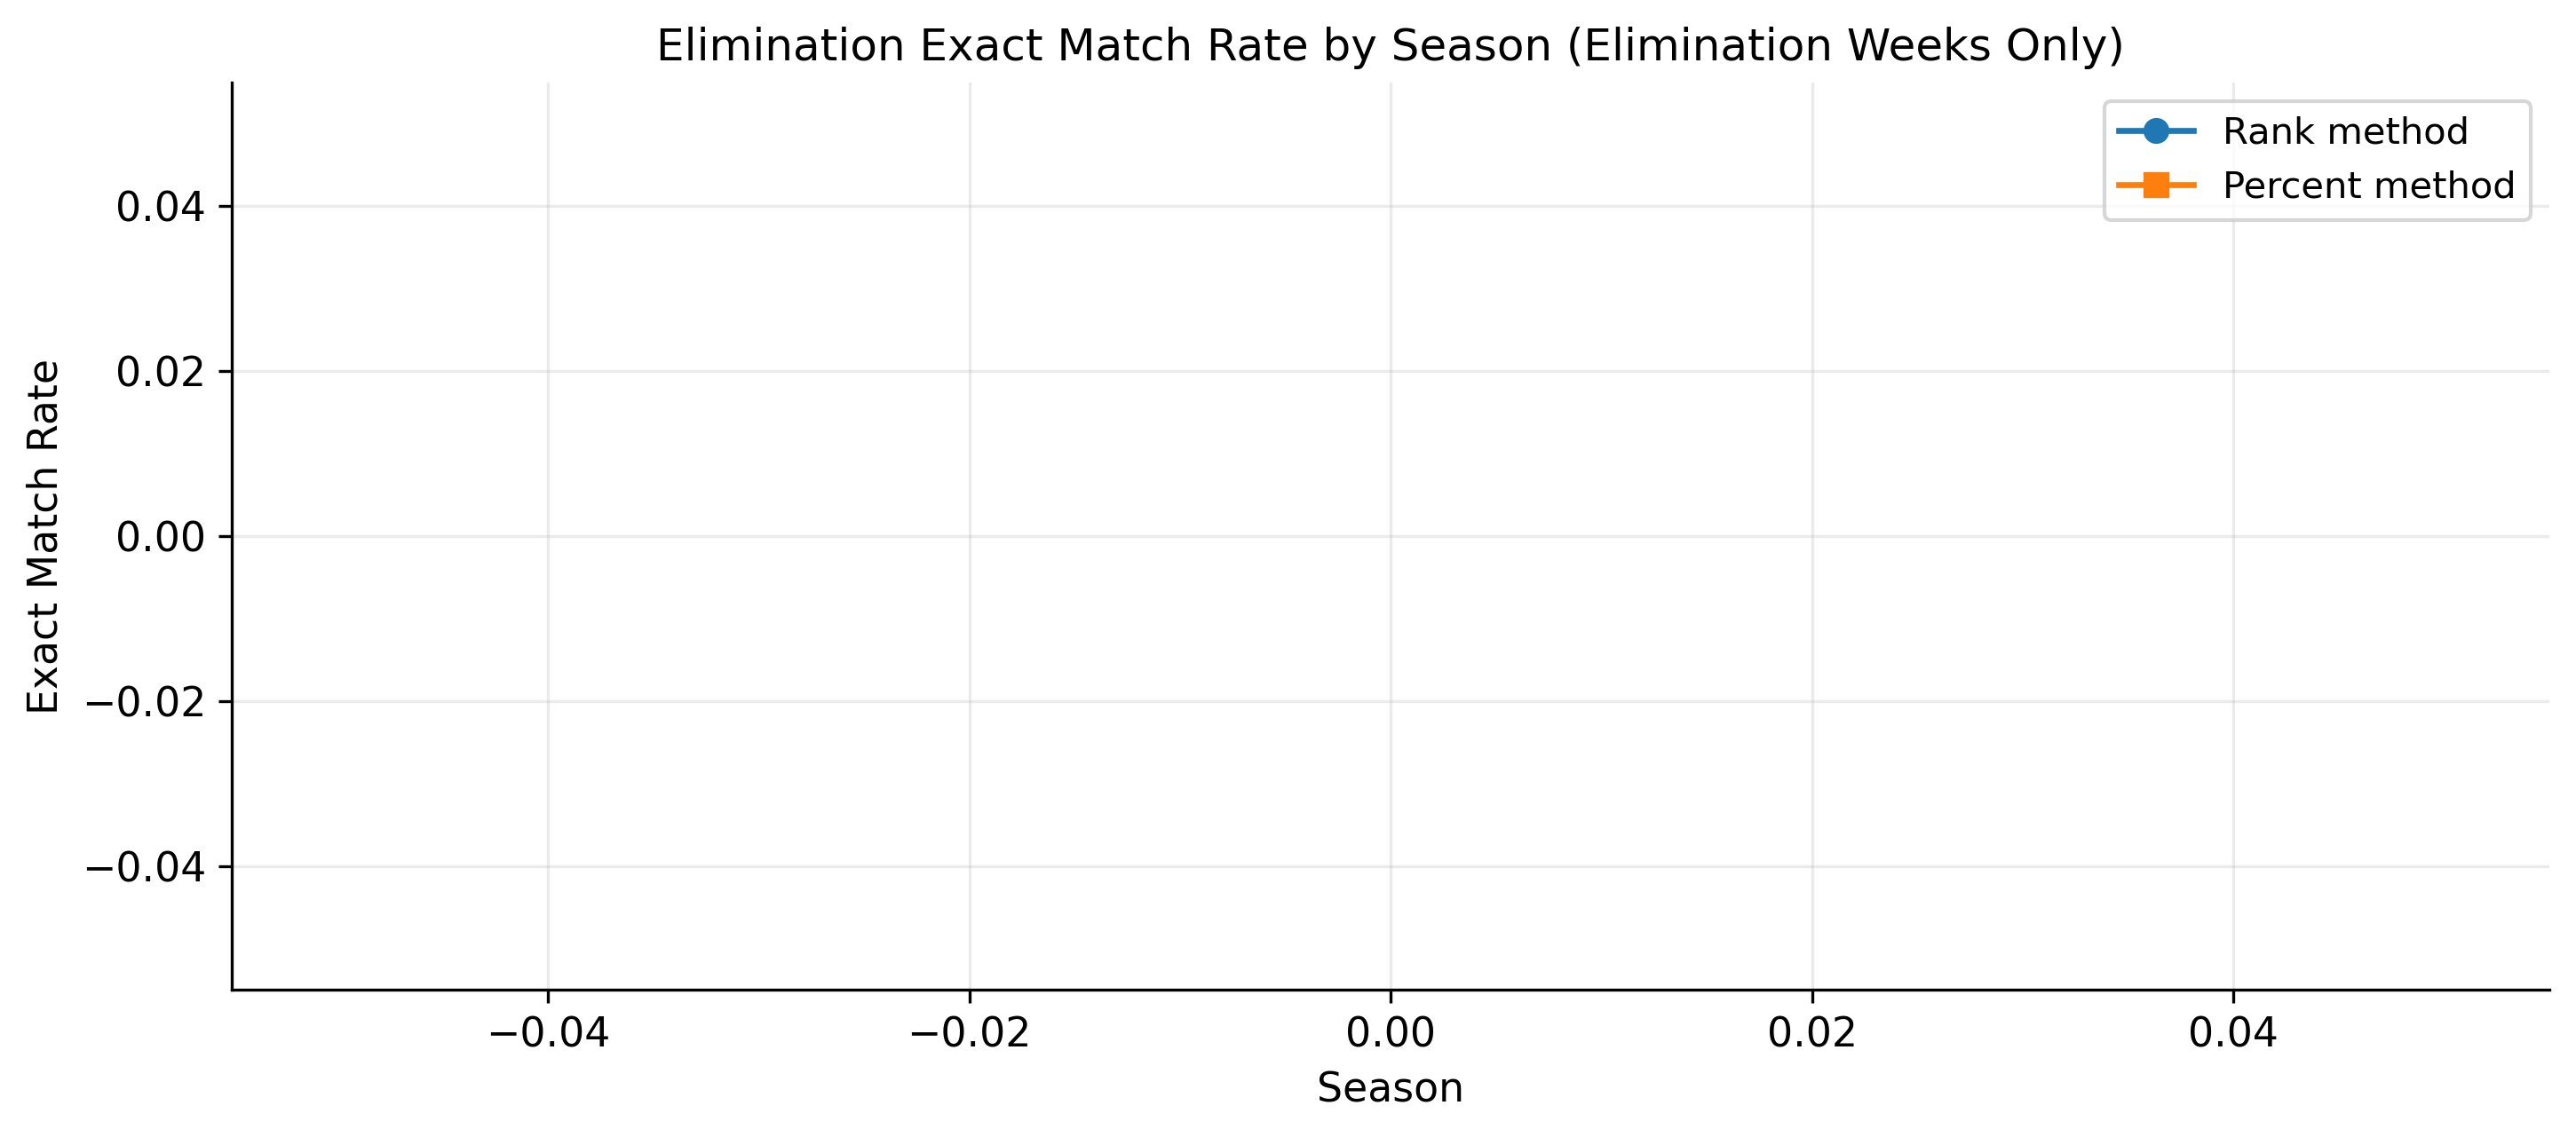

In [13]:
# ============================================================
# 7) 可视化：跨季对比
# ============================================================

# 7.1 两方法淘汰一致率（按赛季）
plt.figure(figsize=(9.8, 4.4), dpi=300)
plt.plot(season_agg["season"], season_agg["rank_exact_elim"], marker="o", label="Rank method")
plt.plot(season_agg["season"], season_agg["pct_exact_elim"], marker="s", label="Percent method")
plt.title("Elimination Exact Match Rate by Season (Elimination Weeks Only)")
plt.xlabel("Season")
plt.ylabel("Exact Match Rate")
plt.legend()
plt.tight_layout()
plt.show()

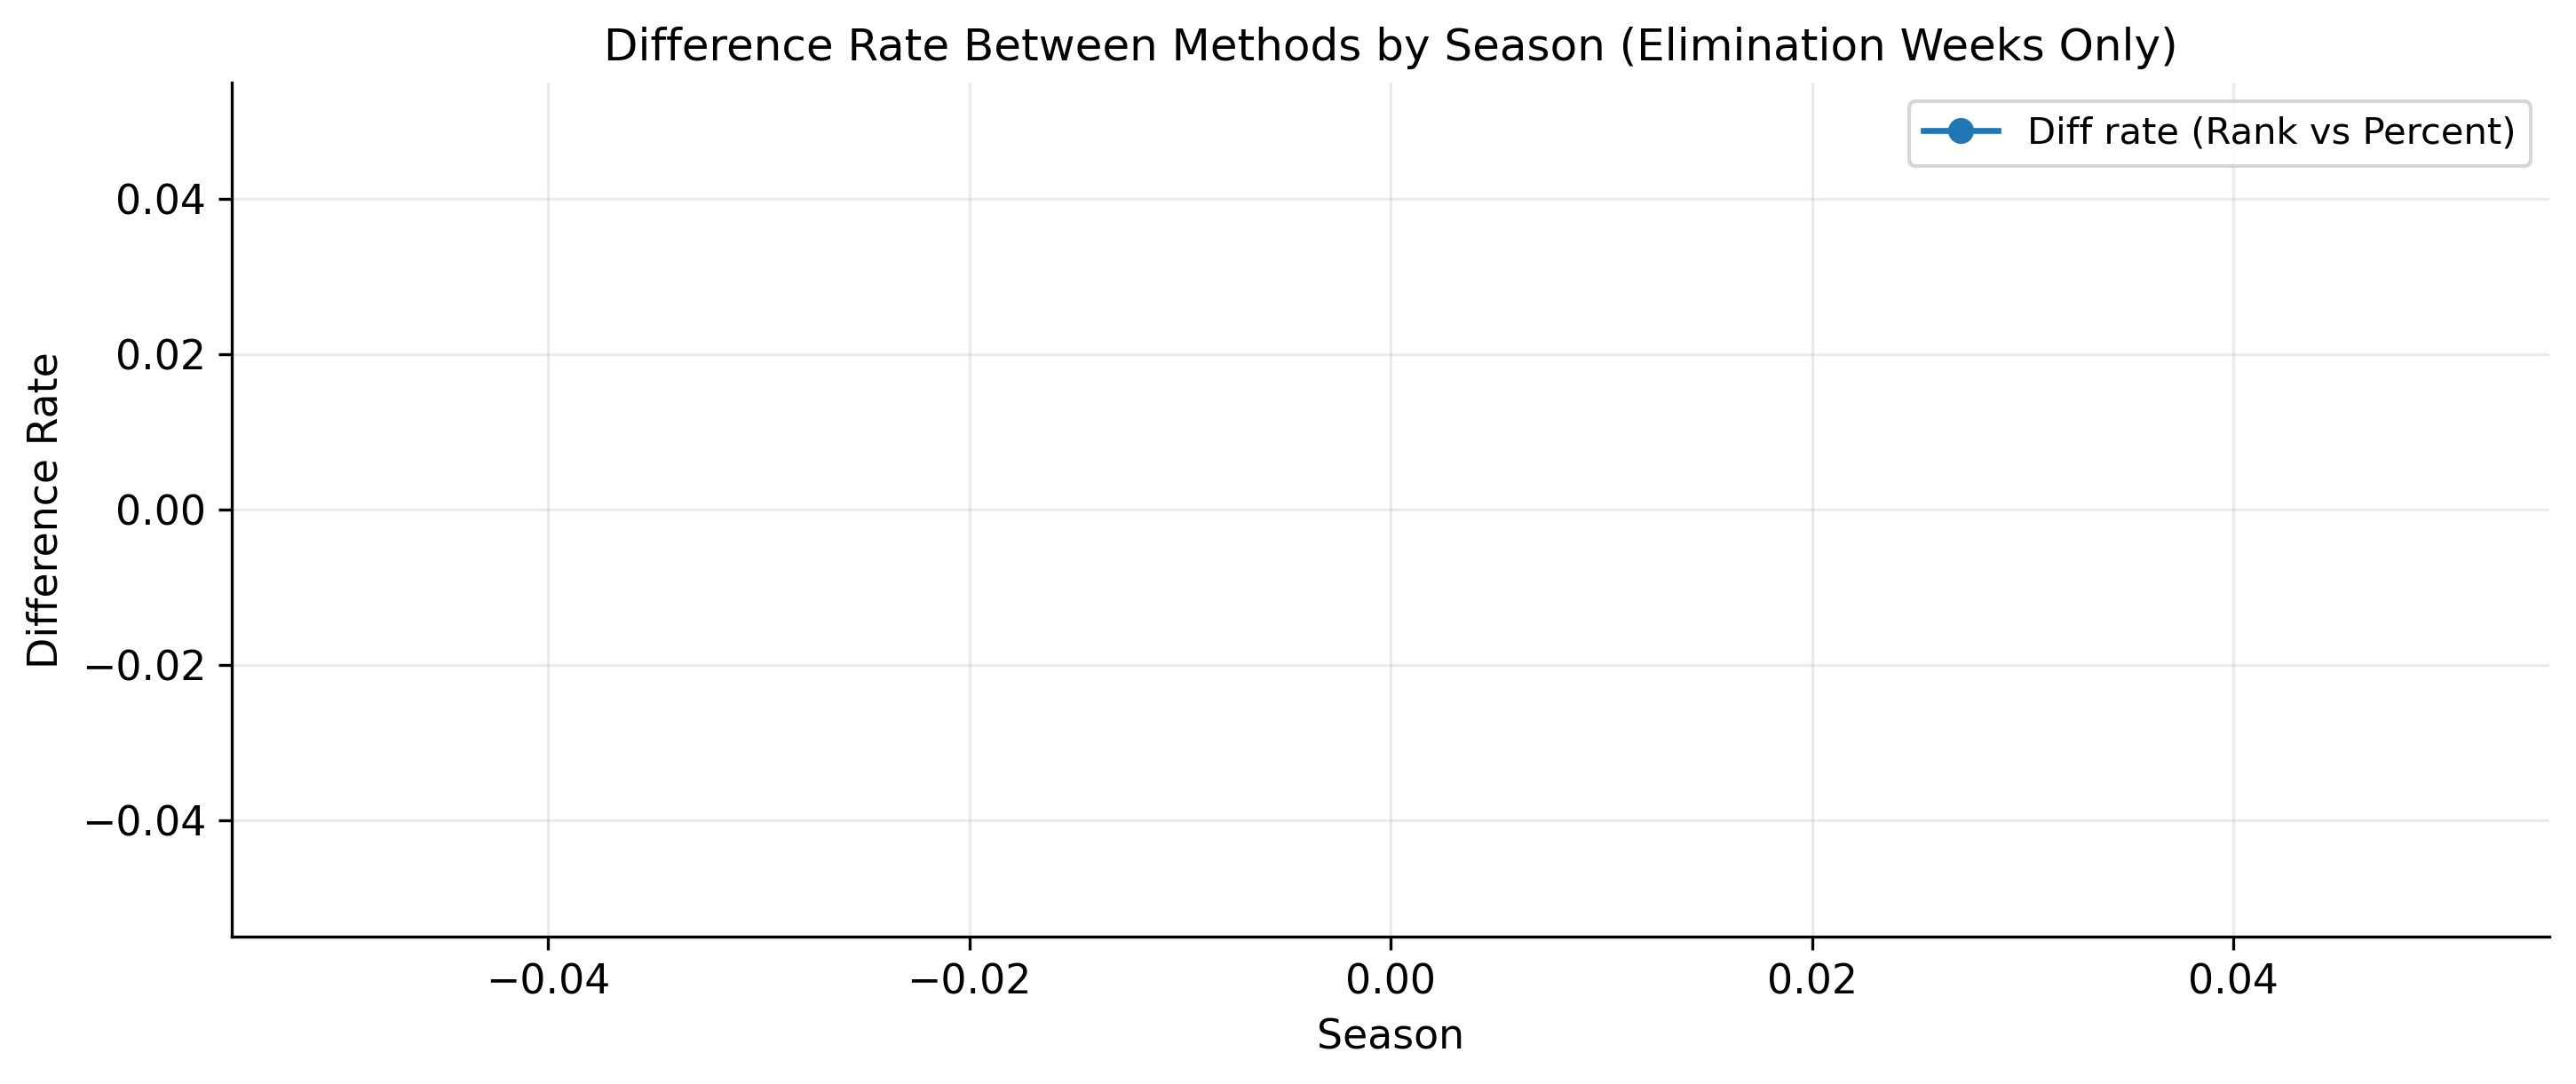

In [14]:
# 7.2 两方法淘汰差异率（按赛季）
plt.figure(figsize=(9.8, 4.2), dpi=300)
plt.plot(season_agg["season"], season_agg["diff_rate_elim"], marker="o", label="Diff rate (Rank vs Percent)")
plt.title("Difference Rate Between Methods by Season (Elimination Weeks Only)")
plt.xlabel("Season")
plt.ylabel("Difference Rate")
plt.legend()
plt.tight_layout()
plt.show()


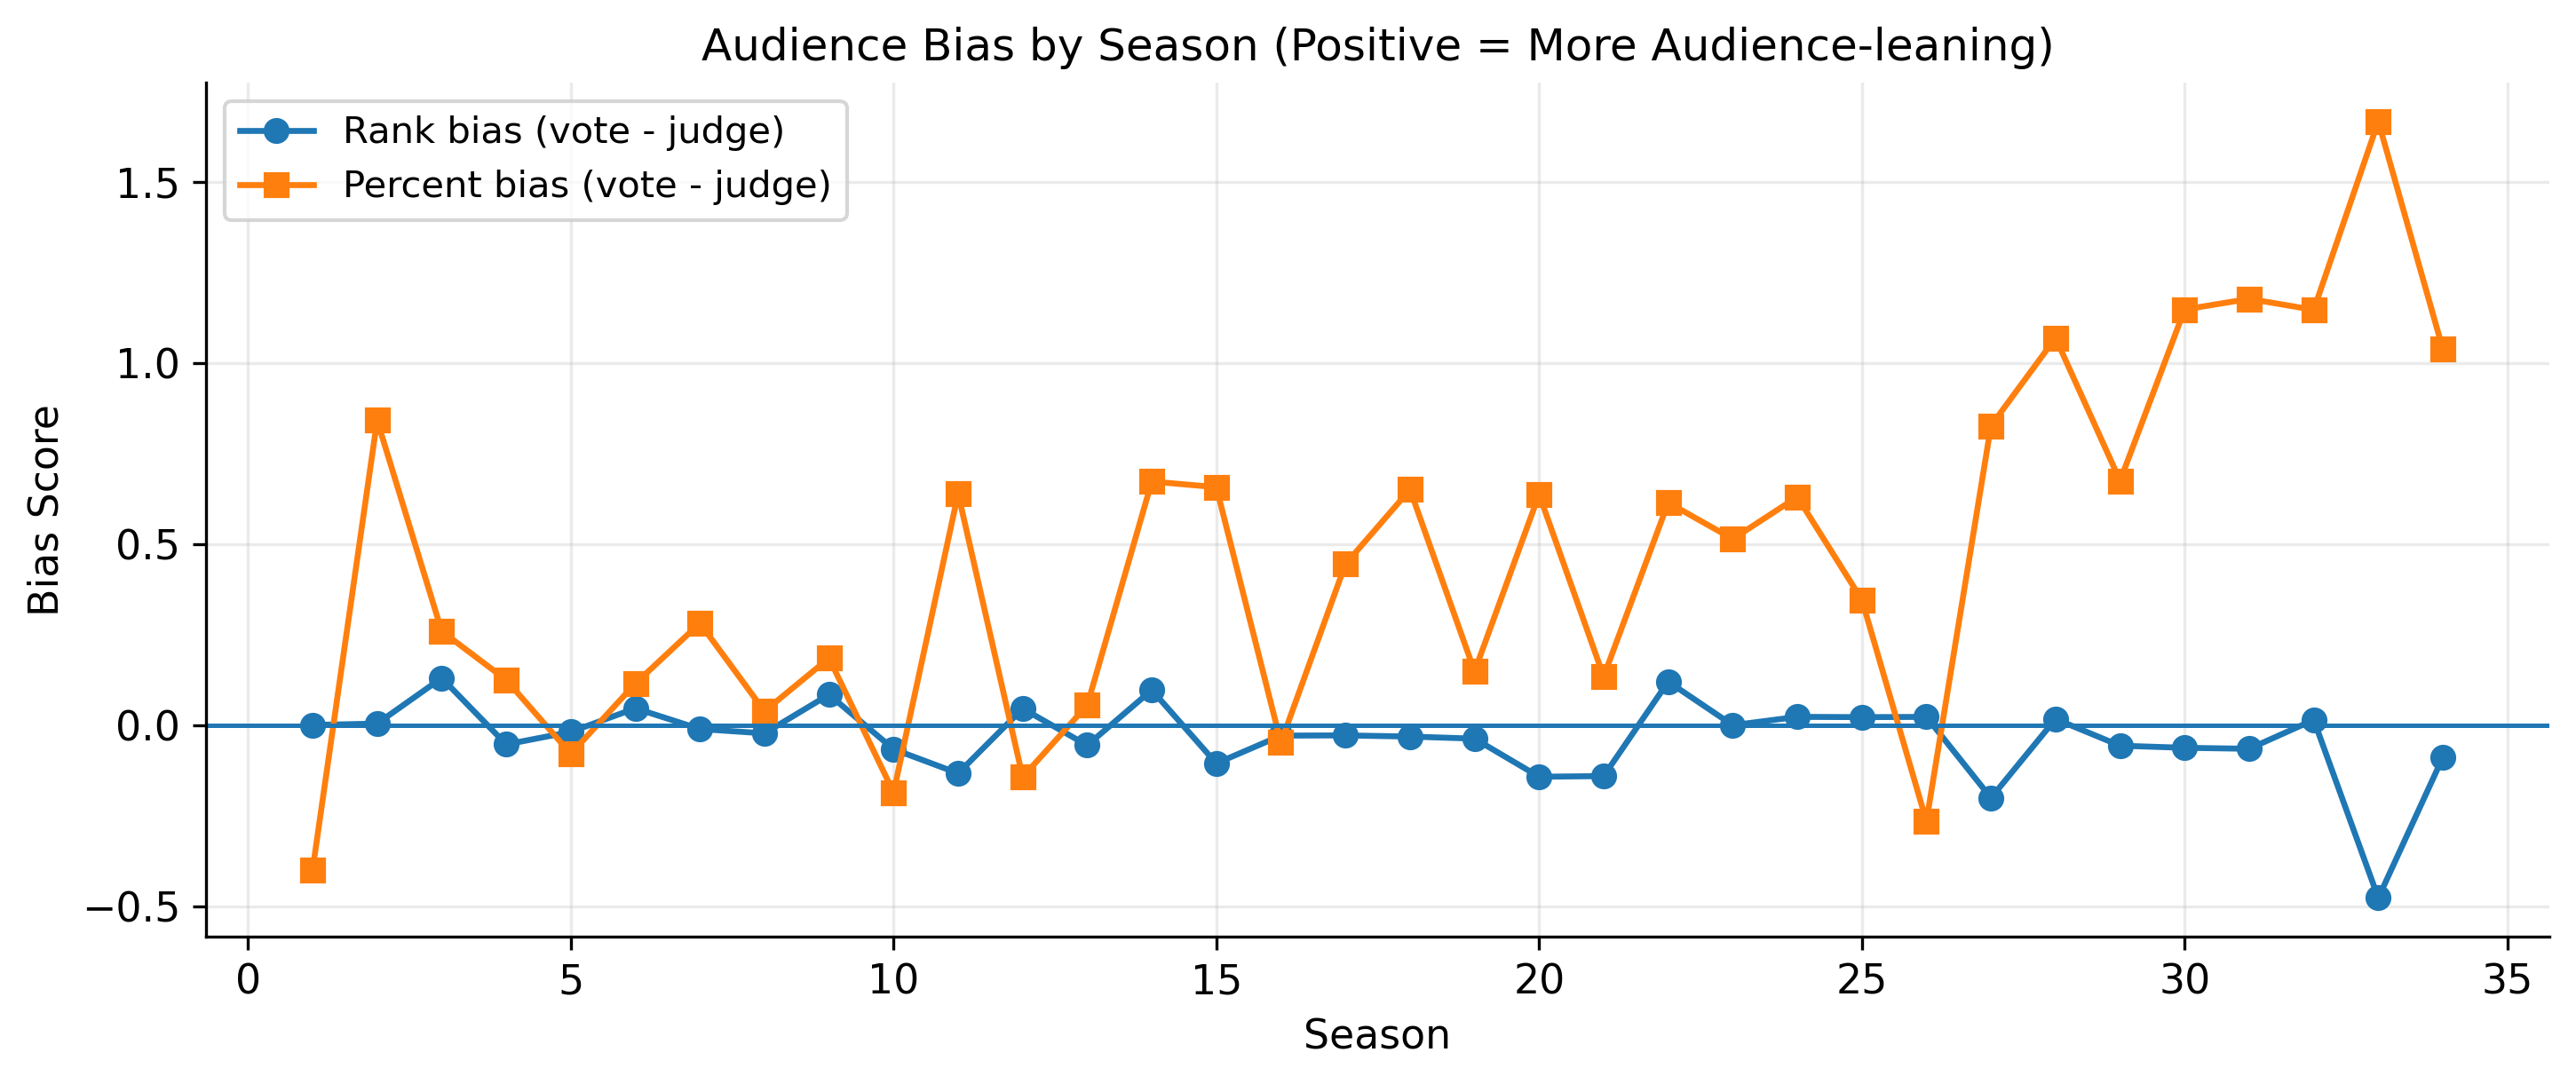

In [15]:
# 7.3 偏向观众 bias（按赛季）
plt.figure(figsize=(9.8, 4.2), dpi=300)
plt.plot(season_agg["season"], season_agg["bias_rank_mean"], marker="o", label="Rank bias (vote - judge)")
plt.plot(season_agg["season"], season_agg["bias_pct_mean"], marker="s", label="Percent bias (vote - judge)")
plt.axhline(0, linewidth=1.2)  # 0线：不偏向
plt.title("Audience Bias by Season (Positive = More Audience-leaning)")
plt.xlabel("Season")
plt.ylabel("Bias Score")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 问题2（第2、3小问）：争议案例分析 + 推荐方案（在 2.1 代码基础上续写）

# ============================================================
# 2.2 争议案例分析：自动识别争议周/争议选手 + 四个指定示例逐一分析
# ============================================================

# -----------------------------
# 2.2-0 参数设置：争议阈值与蒙特卡洛扰动强度
# -----------------------------
CONTROV_THRESH = 4      # |评委名次-观众名次| >= 4 视为争议（可调：3~6）
MC_RUNS = 300           # 每个争议周蒙特卡洛次数（可调：200~1000）
MC_SIGMA = 0.10         # 观众票数扰动强度（对数正态噪声，0.05~0.20）
RNG_SEED_22 = 202602
rng22 = np.random.default_rng(RNG_SEED_22)

print("\n【问题2-2】争议分析参数：")
#如果某个选手在某周“评委名次”和“观众名次（你估计的票数）”相差至少 4 名，就算是真正意义上的分歧比较大，值得列为争议
print(f"  争议阈值 |judge_rank - vote_rank| >= {CONTROV_THRESH}")
#回答题目那句“能否确保每位参赛者获得相同结果”，就必须证明“票数稍微有点波动，结果会不会翻盘”。所以这两个参数就是控制你模拟多少次，以及模拟“票数波动幅度”有多大。
print(f"  蒙特卡洛次数 MC_RUNS = {MC_RUNS}")
print(f"  票数扰动强度 MC_SIGMA = {MC_SIGMA}")

# -----------------------------
# 2.2-1 构建周内名次、分歧程度（基于 df_votes）
# -----------------------------
df_work = df_votes.copy()


【问题2-2】争议分析参数：
  争议阈值 |judge_rank - vote_rank| >= 4
  蒙特卡洛次数 MC_RUNS = 300
  票数扰动强度 MC_SIGMA = 0.1


在 df_votes 的基础上给每个赛季每周重新算两个名次：judge_rank 表示这周评委给分从高到低排第几，vote_rank 表示这周你估出来的票数从高到低排第几。你会看到它计算了 rank_gap = judge_rank - vote_rank，以及绝对值 abs_gap。这一步的直觉就是：如果一个人评委排很后面但观众排很前面，那就说明典型的“评委不喜欢但观众很买账”；反过来就是“评委觉得很强但观众不投”。你后面所有争议案例，其实都是在这一套差异量化上做文章。最后它顺手把 abs_gap >= 阈值 的标为 is_controversy，并且统计争议行数、争议周汇总（一个周里有几个争议选手、争议占比是多少），让你对整体争议程度先有个直观印象。

In [17]:
# 周内计算评委名次、观众名次（越小越好）
df_work["judge_rank"] = df_work.groupby(["season", "week"])["judge_total"].rank(ascending=False, method="min")
df_work["vote_rank"]  = df_work.groupby(["season", "week"])["votes_hat"].rank(ascending=False, method="min")
df_work["rank_gap"]   = df_work["judge_rank"] - df_work["vote_rank"]
df_work["abs_gap"]    = df_work["rank_gap"].abs()

# 标记争议事件
df_work["is_controversy"] = df_work["abs_gap"] >= CONTROV_THRESH

print("\n【问题2-2】争议事件总体规模：")
print("  总行数（选手-周） =", len(df_work))
print("  争议行数（abs_gap>=阈值） =", int(df_work["is_controversy"].sum()))

# 按周汇总争议数量
wk_contro = (
    df_work.groupby(["season", "week"], as_index=False)
    .agg(
        n_active=("celebrity_name", "count"),
        n_contro=("is_controversy", "sum"),#当周争议选手数量
        max_abs_gap=("abs_gap", "max"),#当周最大分歧强度最极端的那个选手，评委排名和观众排名差了多少名。
        mean_abs_gap=("abs_gap", "mean")#这一周所有选手，评委-观众排名差距的平均值。
    )
)
wk_contro["contro_rate"] = wk_contro["n_contro"] / wk_contro["n_active"] #争议比例 / 争议密度 即是否“争议集中爆发”
print("\n【问题2-2】争议周汇总（前10行）：")
display(wk_contro.sort_values(["contro_rate","max_abs_gap"], ascending=False).head(10))



【问题2-2】争议事件总体规模：
  总行数（选手-周） = 1773
  争议行数（abs_gap>=阈值） = 767

【问题2-2】争议周汇总（前10行）：


,season,week,n_active,n_contro,max_abs_gap,mean_abs_gap,contro_rate
170,27,2,12,12,11.0,6.083333,1.000000
190,30,3,14,13,10.0,6.928571,0.928571
192,30,5,11,10,10.0,5.727273,0.909091
199,31,4,13,11,12.0,6.230769,0.846154
205,32,2,13,11,9.0,5.230769,0.846154
207,32,4,11,9,8.0,4.818182,0.818182
116,18,3,9,7,7.0,4.444444,0.777778
206,32,3,12,9,10.0,5.583333,0.750000
98,15,5,8,6,6.0,4.500000,0.750000
80,13,2,11,8,10.0,5.090909,0.727273


In [18]:
# -----------------------------
# 2.2-2 规则假设：当季“节目实际规则”（用于对照 A）
#   - 题面给出：S1-2 排名法；S3-27 百分比法；S28+ 回归排名法（并可有评委二选一机制）
# -----------------------------
def season_default_method(season: int) -> str:  # 定义：当季默认赛制（用于 A 对照）
    if season in [1, 2]:  # S1-2 排名法
        return "rank"  # 返回 rank
    if 3 <= season <= 27:  # S3-27 百分比法
        return "percent"  # 返回 percent
    return "rank"  # S28+ 合理假设回归排名法

def run_method_on_week(g: pd.DataFrame, method: str, k: int):  # 定义：对某周运行指定方法并返回淘汰/底二/全表
    if method == "rank":  # 若方法是排名法
        gg = engine_rank_method(g)  # 跑排名法引擎
        elim_set = pick_eliminated(gg, k)  # 取淘汰集合
        bottom2 = gg["celebrity_name"].head(2).tolist()  # 取 bottom2（最差两位）
        return elim_set, bottom2, gg  # 返回
    else:  # 否则是百分比法
        gg = engine_percent_method(g)  # 跑百分比法引擎
        elim_set = pick_eliminated(gg, k)  # 取淘汰集合
        bottom2 = gg["celebrity_name"].head(2).tolist()  # 取 bottom2
        return elim_set, bottom2, gg  # 返回

def apply_judges_save(g: pd.DataFrame, bottom2: list, k: int):  # 定义：评委二选一机制（类似 S28）
    """
    增加“最后两名评委裁决淘汰”的机制：
    - 仅对单淘汰（k=1）启用
    - 在 bottom2 内淘汰 judge_total 更低者（模拟评委更偏技术）
    """  # 规则说明（中文）
    if k != 1 or len(bottom2) < 2:  # 若不是单淘汰或 bottom2 不足两人
        return None  # 返回 None 表示不适用

    gg = g.set_index("celebrity_name")  # 将明星名设为索引，便于查分
    a, b = bottom2[0], bottom2[1]  # 取 bottom2 的两人
    ja = gg.loc[a, "judge_total"] if a in gg.index else np.nan  # a 的评委分
    jb = gg.loc[b, "judge_total"] if b in gg.index else np.nan  # b 的评委分

    if np.isfinite(ja) and np.isfinite(jb):  # 如果评委分都有效
        elim = a if ja < jb else b  # 淘汰评委分更低者
    else:  # 如果评委分缺失（兜底）
        va = gg.loc[a, "votes_hat"] if a in gg.index else np.nan  # a 票数
        vb = gg.loc[b, "votes_hat"] if b in gg.index else np.nan  # b 票数
        elim = a if va < vb else b  # 淘汰票数更低者

    return {elim}  # 返回淘汰集合（set）


In [19]:
# -----------------------------
# 2.2-3 蒙特卡洛：对某个争议周的票数做合理扰动，看淘汰结果是否“翻转”
# -----------------------------
def mc_stability_test(g: pd.DataFrame, method: str, k: int, mc_runs: int, sigma: float, rng: np.random.Generator):
    """
    输出：
      - flip_rate：淘汰结果改变的比例（相对基准票数）
      - elim_dist：每个被淘汰者出现的频率
      - base_elim：基准淘汰集合
      - base_bottom2：基准 bottom2
      - flip_rate_judges_save：加入评委二选一后的翻转率
      - elim_dist_judges_save：加入机制后淘汰分布
    """
    # 基准（不扰动）
    base_elim, base_bottom2, _ = run_method_on_week(g, method, k)

    # 评委二选一基准
    base_elim_js = None
    if k == 1:
        js = apply_judges_save(g, base_bottom2, k)
        base_elim_js = js if js is not None else base_elim

    # 为了不破坏周内份额结构，使用“对每位选手票数乘以独立 lognormal 因子”的方式
    # （更严格也可对同周票池乘共同因子，但这里主要看排序翻转，个体因子更能放大不稳定性）
    mu = -0.5 * (sigma ** 2)

    flip = 0
    elim_counter = {}

    flip_js = 0
    elim_counter_js = {}

    for _ in range(mc_runs):
        gg = g.copy()
        factors = np.exp(rng.normal(loc=mu, scale=sigma, size=len(gg)))
        gg["votes_hat"] = gg["votes_hat"].values * factors

        # 原方法
        elim_set, bottom2, _ = run_method_on_week(gg, method, k)
        if elim_set != base_elim:
            flip += 1
        for name in elim_set:
            elim_counter[name] = elim_counter.get(name, 0) + 1

        # 加入评委二选一（仅k=1）
        if k == 1:
            elim_js = apply_judges_save(gg, bottom2, k)
            elim_js = elim_js if elim_js is not None else elim_set
            if elim_js != base_elim_js:
                flip_js += 1
            for name in elim_js:
                elim_counter_js[name] = elim_counter_js.get(name, 0) + 1

    flip_rate = flip / mc_runs
    elim_dist = {k: v / mc_runs for k, v in elim_counter.items()}

    if k == 1:
        flip_rate_js = flip_js / mc_runs
        elim_dist_js = {k: v / mc_runs for k, v in elim_counter_js.items()}
    else:
        flip_rate_js = np.nan
        elim_dist_js = {}

    return {
        "base_elim": sorted(list(base_elim)),
        "base_bottom2": base_bottom2,
        "flip_rate": float(flip_rate),
        "elim_dist": elim_dist,
        "base_elim_judges_save": sorted(list(base_elim_js)) if isinstance(base_elim_js, set) else base_elim_js,
        "flip_rate_judges_save": float(flip_rate_js) if np.isfinite(flip_rate_js) else np.nan,
        "elim_dist_judges_save": elim_dist_js
    }


In [20]:
# -----------------------------
# 2.2-4 自动提取“最争议的事件”：全局TopN + 每季TopK
# -----------------------------
# 只看“淘汰周”更贴近题意（k>0）
true_k_map = q2_wk.set_index(["season","week"])["true_k"].to_dict()
df_work["true_k"] = df_work.apply(lambda r: int(true_k_map.get((int(r["season"]), int(r["week"])), 0)), axis=1)

contro_events = df_work[(df_work["is_controversy"]) & (df_work["true_k"] > 0)].copy()
contro_events = contro_events.sort_values(["abs_gap", "season", "week"], ascending=[False, True, True])

print("\n【问题2-2】自动识别：最争议事件 Top20（淘汰周内）：")
display(contro_events[["season","week","celebrity_name","judge_rank","vote_rank","rank_gap","abs_gap"]].head(20))




【问题2-2】自动识别：最争议事件 Top20（淘汰周内）：


,season,week,celebrity_name,judge_rank,vote_rank,rank_gap,abs_gap


In [21]:
# 全局挑选 TopN（避免过多计算）
TOPN_GLOBAL = 25
contro_global_top = contro_events.head(TOPN_GLOBAL).copy()

# -----------------------------
# 2.2-5 四个指定示例：尽量在对应季中匹配到该明星（若名字拼写不同，用包含匹配）
# -----------------------------
def find_celebrity_in_season(season: int, keyword_list: list):
    """
    在给定 season 中根据若干关键词（大小写不敏感）找最可能的 celebrity_name
    返回：匹配到的名字（或 None）以及候选表
    """
    names = df_work[df_work["season"] == season]["celebrity_name"].dropna().unique().tolist()
    low_map = {n: str(n).lower() for n in names}

    # 先严格包含匹配
    for kw in keyword_list:
        kwl = kw.lower()
        candidates = [n for n, nl in low_map.items() if kwl in nl]
        if len(candidates) == 1:
            return candidates[0], candidates
        if len(candidates) > 1:
            # 多个候选时，返回候选最多的（后续人工可看 candidates）
            return candidates[0], candidates

    # 兜底：无匹配
    return None, []

In [22]:
# 题目指定示例（季、关键词）
examples = [
    {"season": 2,  "label": "S2 Jerry Rice",       "keywords": ["jerry", "rice"]},
    {"season": 4,  "label": "S4 Billy Ray Cyrus",  "keywords": ["billy", "cyrus", "ray"]},
    {"season": 11, "label": "S11 Bristol Palin",   "keywords": ["bristol", "palin"]},
    {"season": 27, "label": "S27 Bobby Bones",     "keywords": ["bobby", "bones"]},
]

example_matches = []
for ex in examples:
    name, cands = find_celebrity_in_season(ex["season"], ex["keywords"])
    example_matches.append({
        "season": ex["season"],
        "label": ex["label"],
        "matched_name": name,
        "candidates": cands
    })



In [23]:
# -----------------------------
# 2.2-6 对“争议事件”做三套反事实模拟：
#   A）当季默认规则（rank / percent）
#   B）强制 rank
#   C）强制 percent
#   并加入“评委二选一”对比稳定性（蒙特卡洛翻转率）
# -----------------------------
def analyze_one_event(season: int, week: int, focus_name: str = None, do_mc: bool = True):
    """
    返回：一个 dict（含当周摘要、三种方法淘汰结果、是否与真实一致、争议程度、蒙特卡洛稳定性等）
    """
    g = df_votes[(df_votes["season"] == season) & (df_votes["week"] == week)].copy()
    if len(g) == 0:
        return None

    true_set = true_map.get((season, week), set())
    k = len(true_set)

    # 争议指标：若 focus_name 给了，就取该人；否则取该周 abs_gap 最大的人
    g2 = df_work[(df_work["season"] == season) & (df_work["week"] == week)].copy()
    if len(g2) == 0:
        return None

    if focus_name is not None and (focus_name in g2["celebrity_name"].values):
        row_focus = g2[g2["celebrity_name"] == focus_name].iloc[0]
    else:
        row_focus = g2.sort_values("abs_gap", ascending=False).iloc[0]

    # 三套方法
    default_m = season_default_method(season)
    elim_A, bottom2_A, _ = run_method_on_week(g, default_m, k)
    elim_B, bottom2_B, _ = run_method_on_week(g, "rank", k)
    elim_C, bottom2_C, _ = run_method_on_week(g, "percent", k)

    # 加入“评委二选一”（仅单淘汰周有意义）
    elim_A_js = apply_judges_save(g, bottom2_A, k) if (k == 1) else None
    elim_B_js = apply_judges_save(g, bottom2_B, k) if (k == 1) else None
    elim_C_js = apply_judges_save(g, bottom2_C, k) if (k == 1) else None

    # 与真值一致
    exact_A = int((elim_A == true_set) if k > 0 else True)
    exact_B = int((elim_B == true_set) if k > 0 else True)
    exact_C = int((elim_C == true_set) if k > 0 else True)

    # 蒙特卡洛稳定性（只对“争议周 & 有淘汰周”跑更有意义）
    mc_out = {}
    if do_mc and k > 0:
        mc_out[f"MC_{default_m}"] = mc_stability_test(g, default_m, k, MC_RUNS, MC_SIGMA, rng22)
        mc_out["MC_rank"]         = mc_stability_test(g, "rank",    k, MC_RUNS, MC_SIGMA, rng22)
        mc_out["MC_percent"]      = mc_stability_test(g, "percent", k, MC_RUNS, MC_SIGMA, rng22)

    return {
        "season": season,
        "week": week,
        "true_k": k,
        "true_eliminated": sorted(list(true_set)),

        "focus_celebrity": str(row_focus["celebrity_name"]),
        "focus_judge_rank": float(row_focus["judge_rank"]),
        "focus_vote_rank": float(row_focus["vote_rank"]),
        "focus_rank_gap": float(row_focus["rank_gap"]),
        "focus_abs_gap": float(row_focus["abs_gap"]),

        "A_default_method": default_m,
        "A_eliminated": sorted(list(elim_A)),
        "A_exact_match": int(exact_A),
        "A_bottom2": bottom2_A,
        "A_eliminated_judges_save": sorted(list(elim_A_js)) if isinstance(elim_A_js, set) else None,

        "B_eliminated_rank": sorted(list(elim_B)),
        "B_exact_match": int(exact_B),
        "B_bottom2": bottom2_B,
        "B_eliminated_rank_judges_save": sorted(list(elim_B_js)) if isinstance(elim_B_js, set) else None,

        "C_eliminated_percent": sorted(list(elim_C)),
        "C_exact_match": int(exact_C),
        "C_bottom2": bottom2_C,
        "C_eliminated_percent_judges_save": sorted(list(elim_C_js)) if isinstance(elim_C_js, set) else None,

        "mc": mc_out
    }


In [24]:
# -----------------------------
# 2.2-7 先分析四个指定示例：逐一输出
# -----------------------------
example_reports = []
for ex in example_matches:
    s = ex["season"]
    name = ex["matched_name"]
    if name is None:
        print(f"\n【问题2-2】警告：{ex['label']} 未在 Season {s} 中匹配到姓名，将改为该季争议最大事件进行分析。")
    # 为了回答题目要求：即使匹配不到，也要给出一个可解释分析（但你最好补齐名字）
    rep = analyze_one_event(s, week=1, focus_name=name, do_mc=False)

    # 如果 week=1 不是争议周/无数据，则在该季内自动找“该选手 abs_gap 最大的周”
    if name is not None:
        cand = df_work[(df_work["season"] == s) & (df_work["celebrity_name"] == name) & (df_work["true_k"] > 0)].copy()
        if len(cand) > 0:
            cand = cand.sort_values("abs_gap", ascending=False)
            w_best = int(cand.iloc[0]["week"])
            rep = analyze_one_event(s, week=w_best, focus_name=name, do_mc=True)
        else:
            # 该选手在淘汰周没有被判为争议（可能阈值太高），仍选择该选手 abs_gap 最大周（不要求 true_k>0）
            cand2 = df_work[(df_work["season"] == s) & (df_work["celebrity_name"] == name)].copy()
            if len(cand2) > 0:
                cand2 = cand2.sort_values("abs_gap", ascending=False)
                w_best = int(cand2.iloc[0]["week"])
                rep = analyze_one_event(s, week=w_best, focus_name=name, do_mc=True)
            else:
                rep = None
    else:
        # 无法匹配姓名：选该季“abs_gap 最大的淘汰周事件”
        cand = df_work[(df_work["season"] == s) & (df_work["true_k"] > 0)].sort_values("abs_gap", ascending=False)
        if len(cand) > 0:
            w_best = int(cand.iloc[0]["week"])
            rep = analyze_one_event(s, week=w_best, focus_name=None, do_mc=True)
        else:
            rep = None

    if rep is not None:
        rep["example_label"] = ex["label"]
        rep["matched_name"] = name
        example_reports.append(rep)

print("\n【问题2-2】四个示例逐一分析结果（摘要打印）：")
for rep in example_reports:
    print(f"\n  示例：{rep.get('example_label')}")
    print(f"  赛季/周：S{rep['season']} W{rep['week']}  true_elim={rep['true_eliminated']}")
    print(f"  争议明星：{rep['focus_celebrity']}  judge_rank={rep['focus_judge_rank']} vote_rank={rep['focus_vote_rank']} abs_gap={rep['focus_abs_gap']}")
    print(f"  A(默认={rep['A_default_method']}): elim={rep['A_eliminated']}  match={rep['A_exact_match']}  bottom2={rep['A_bottom2']}")
    print(f"  B(强制rank): elim={rep['B_eliminated_rank']}  match={rep['B_exact_match']}  bottom2={rep['B_bottom2']}")
    print(f"  C(强制percent): elim={rep['C_eliminated_percent']}  match={rep['C_exact_match']}  bottom2={rep['C_bottom2']}")
    if rep["true_k"] == 1 and len(rep["mc"]) > 0:
        mcA = rep["mc"].get(f"MC_{rep['A_default_method']}", {})
        print(f"  稳定性(默认方法)：翻转率={mcA.get('flip_rate', np.nan):.3f}；加入评委二选一后翻转率={mcA.get('flip_rate_judges_save', np.nan):.3f}")


【问题2-2】四个示例逐一分析结果（摘要打印）：

  示例：S2 Jerry Rice
  赛季/周：S2 W5  true_elim=[]
  争议明星：Jerry Rice  judge_rank=5.0 vote_rank=2.0 abs_gap=3.0
  A(默认=rank): elim=[]  match=1  bottom2=['Tia Carrere', 'Drew Lachey']
  B(强制rank): elim=[]  match=1  bottom2=['Tia Carrere', 'Drew Lachey']
  C(强制percent): elim=[]  match=1  bottom2=['Drew Lachey', 'Tia Carrere']

  示例：S4 Billy Ray Cyrus
  赛季/周：S4 W6  true_elim=[]
  争议明星：Billy Ray Cyrus  judge_rank=6.0 vote_rank=2.0 abs_gap=4.0
  A(默认=percent): elim=[]  match=1  bottom2=['Heather Mills', 'Apolo Anton Ohno']
  B(强制rank): elim=[]  match=1  bottom2=['Heather Mills', 'Joey Fatone']
  C(强制percent): elim=[]  match=1  bottom2=['Heather Mills', 'Apolo Anton Ohno']

  示例：S11 Bristol Palin
  赛季/周：S11 W3  true_elim=[]
  争议明星：Bristol Palin  judge_rank=9.0 vote_rank=2.0 abs_gap=7.0
  A(默认=percent): elim=[]  match=1  bottom2=['Margaret Cho', 'Audrina Patridge']
  B(强制rank): elim=[]  match=1  bottom2=['Margaret Cho', 'Bristol Palin']
  C(强制percent): elim=[]  match=1  b

In [25]:
# -----------------------------
# 2.2-8 自动争议TopN事件批量分析（用于“是否能确保每位参赛者获得相同结果”）
#   - 我们对争议TopN事件做蒙特卡洛，统计翻转率分布
# -----------------------------
auto_reports = []
for r in contro_global_top.itertuples(index=False):
    s = int(r.season); w = int(r.week)
    rep = analyze_one_event(s, w, focus_name=str(r.celebrity_name), do_mc=True)
    if rep is not None:
        rep["auto_flag"] = 1
        auto_reports.append(rep)

print("\n【问题2-2】自动争议Top事件分析完成：", len(auto_reports))
# 将报告结构化成 DataFrame（便于保存与画图）
def flatten_report(rep: dict, tag: str):
    """把 report 的关键字段拉平成一行，蒙特卡洛只取翻转率"""
    row = {
        "tag": tag,
        "season": rep["season"],
        "week": rep["week"],
        "true_k": rep["true_k"],
        "true_eliminated": rep["true_eliminated"],
        "focus_celebrity": rep["focus_celebrity"],
        "focus_abs_gap": rep["focus_abs_gap"],
        "A_default_method": rep["A_default_method"],
        "A_elim": rep["A_eliminated"],
        "B_elim_rank": rep["B_eliminated_rank"],
        "C_elim_percent": rep["C_eliminated_percent"],
        "A_exact": rep["A_exact_match"],
        "B_exact": rep["B_exact_match"],
        "C_exact": rep["C_exact_match"],
    }

    # 蒙特卡洛翻转率
    if rep["true_k"] > 0 and isinstance(rep.get("mc", {}), dict) and len(rep["mc"]) > 0:
        mA = rep["mc"].get(f"MC_{rep['A_default_method']}", {})
        mB = rep["mc"].get("MC_rank", {})
        mC = rep["mc"].get("MC_percent", {})
        row.update({
            "flip_A": mA.get("flip_rate", np.nan),
            "flip_A_judges_save": mA.get("flip_rate_judges_save", np.nan),
            "flip_rank": mB.get("flip_rate", np.nan),
            "flip_rank_judges_save": mB.get("flip_rate_judges_save", np.nan),
            "flip_percent": mC.get("flip_rate", np.nan),
            "flip_percent_judges_save": mC.get("flip_rate_judges_save", np.nan),
        })
    else:
        row.update({
            "flip_A": np.nan, "flip_A_judges_save": np.nan,
            "flip_rank": np.nan, "flip_rank_judges_save": np.nan,
            "flip_percent": np.nan, "flip_percent_judges_save": np.nan,
        })
    return row

rows_flat = []
for rep in example_reports:
    rows_flat.append(flatten_report(rep, tag="example"))
for rep in auto_reports:
    rows_flat.append(flatten_report(rep, tag="auto_top_contro"))

contro_report_df = pd.DataFrame(rows_flat)
print("\n【问题2-2】争议分析汇总表预览：")
contro_report_df.head(12)


【问题2-2】自动争议Top事件分析完成： 0

【问题2-2】争议分析汇总表预览：


,tag,season,week,true_k,true_eliminated,focus_celebrity,focus_abs_gap,A_default_method,A_elim,B_elim_rank,C_elim_percent,A_exact,B_exact,C_exact,flip_A,flip_A_judges_save,flip_rank,flip_rank_judges_save,flip_percent,flip_percent_judges_save
0,example,2,5,0,[],Jerry Rice,3.0,rank,[],[],[],1,1,1,NaN,NaN,NaN,NaN,NaN,NaN
1,example,4,6,0,[],Billy Ray Cyrus,4.0,percent,[],[],[],1,1,1,NaN,NaN,NaN,NaN,NaN,NaN
2,example,11,3,0,[],Bristol Palin,7.0,percent,[],[],[],1,1,1,NaN,NaN,NaN,NaN,NaN,NaN
3,example,27,4,0,[],Bobby Bones,8.0,percent,[],[],[],1,1,1,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
# -----------------------------
# 2.2-9 结论性输出（响应题目要求2）：是否能确保每位参赛者获得相同结果？加入评委二选一影响？
#   - 用翻转率（flip_rate）作为“结果不稳定/不一致”的证据
# -----------------------------
# 只看单淘汰周（k=1）更直观
mask_single = (contro_report_df["true_k"] == 1) & (contro_report_df["tag"] == "auto_top_contro")
tmp_single = contro_report_df.loc[mask_single, ["flip_A","flip_A_judges_save","flip_rank","flip_rank_judges_save","flip_percent","flip_percent_judges_save"]].copy()

print("\n【问题2-2】结论性统计（基于自动争议Top事件，单淘汰周）：")
if len(tmp_single) > 0:
    print("  默认规则翻转率（均值） =", float(np.nanmean(tmp_single["flip_A"])))
    print("  默认规则 + 评委二选一翻转率（均值） =", float(np.nanmean(tmp_single["flip_A_judges_save"])))
    print("  强制排名法翻转率（均值） =", float(np.nanmean(tmp_single["flip_rank"])))
    print("  排名法 + 评委二选一翻转率（均值） =", float(np.nanmean(tmp_single["flip_rank_judges_save"])))
    print("  强制百分比法翻转率（均值） =", float(np.nanmean(tmp_single["flip_percent"])))
    print("  百分比法 + 评委二选一翻转率（均值） =", float(np.nanmean(tmp_single["flip_percent_judges_save"])))
else:
    print("  警告：未得到足够的单淘汰争议事件用于稳定性统计（可适当降低争议阈值或增大TOPN）。")



【问题2-2】结论性统计（基于自动争议Top事件，单淘汰周）：
  警告：未得到足够的单淘汰争议事件用于稳定性统计（可适当降低争议阈值或增大TOPN）。


In [27]:
# -----------------------------
# 2.2-10 可视化：争议周稳定性（翻转率）对比
# -----------------------------
if len(tmp_single) > 0:
    vals = {
        "Default": np.nanmean(tmp_single["flip_A"]),
        "Default+JudgesSave": np.nanmean(tmp_single["flip_A_judges_save"]),
        "Rank": np.nanmean(tmp_single["flip_rank"]),
        "Rank+JudgesSave": np.nanmean(tmp_single["flip_rank_judges_save"]),
        "Percent": np.nanmean(tmp_single["flip_percent"]),
        "Percent+JudgesSave": np.nanmean(tmp_single["flip_percent_judges_save"]),
    }

    plt.figure(figsize=(9.2, 4.2), dpi=300)
    plt.bar(list(vals.keys()), list(vals.values()))
    plt.title("Stability on Controversial Weeks (Flip Rate under Vote Perturbation)")
    plt.xlabel("Scheme")
    plt.ylabel("Flip Rate")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()

In [28]:
# 保存 2.2 输出
out_22 = os.path.join(OUT_DIR, "Q2_part2_controversy_reports_summary.csv")
contro_report_df.to_csv(out_22, index=False, encoding="utf-8-sig")

In [29]:
# ============================================================
# 2.3 推荐未来采用哪种方法？是否建议加入评委二选一？
#   - 汇总 2.1 指标（淘汰一致率、偏向观众） + 2.2 指标（争议数量、稳定性翻转率）

# ============================================================

# -----------------------------
# 2.3-1 构建“争议强度”在赛季层面的度量：每季争议周比例/争议行比例
# -----------------------------
season_contro = (
    wk_contro.merge(q2_wk[["season","week","true_k"]], on=["season","week"], how="left")
)
season_contro["true_k"] = season_contro["true_k"].fillna(0).astype(int)

season_contro_agg = (
    season_contro.groupby("season", as_index=False)
    .agg(
        weeks=("week", "count"),
        elim_weeks=("true_k", lambda x: int((x > 0).sum())),
        contro_weeks=("n_contro", lambda x: int((x > 0).sum())),
        contro_week_rate=("n_contro", lambda x: float((x > 0).mean())),
        mean_contro_rate=("contro_rate", "mean"),
        mean_max_abs_gap=("max_abs_gap", "mean")
    )
)

In [30]:
print("\n【问题2-3】赛季争议统计（前10行）：")
season_contro_agg.head(10)


【问题2-3】赛季争议统计（前10行）：


,season,weeks,elim_weeks,contro_weeks,contro_week_rate,mean_contro_rate,mean_max_abs_gap
0,1,3,0,1,0.333333,0.066667,2.666667
1,2,6,0,5,0.833333,0.283664,5.166667
2,3,7,0,5,0.714286,0.328855,5.000000
3,4,7,0,6,0.857143,0.415590,5.714286
4,5,5,0,3,0.600000,0.237143,4.400000
5,6,7,0,5,0.714286,0.204535,5.714286
6,7,7,0,6,0.857143,0.381102,5.857143
7,8,8,0,7,0.875000,0.351907,6.375000
8,9,8,0,6,0.750000,0.382132,7.000000
9,10,7,0,6,0.857143,0.337642,5.714286


In [31]:
# -----------------------------
# 2.3-2 从 2.2 的蒙特卡洛结果提取“方案稳定性”指标（争议Top事件上）
# -----------------------------
# 仅用 auto_top_contro + 单淘汰周 (k=1) 的平均翻转率作为“争议周稳定性指标”
stability_metrics = {}
if len(tmp_single) > 0:
    stability_metrics = {
        "flip_default_mean": float(np.nanmean(tmp_single["flip_A"])),
        "flip_default_js_mean": float(np.nanmean(tmp_single["flip_A_judges_save"])),
        "flip_rank_mean": float(np.nanmean(tmp_single["flip_rank"])),
        "flip_rank_js_mean": float(np.nanmean(tmp_single["flip_rank_judges_save"])),
        "flip_percent_mean": float(np.nanmean(tmp_single["flip_percent"])),
        "flip_percent_js_mean": float(np.nanmean(tmp_single["flip_percent_judges_save"])),
    }
else:
    stability_metrics = {
        "flip_default_mean": np.nan,
        "flip_default_js_mean": np.nan,
        "flip_rank_mean": np.nan,
        "flip_rank_js_mean": np.nan,
        "flip_percent_mean": np.nan,
        "flip_percent_js_mean": np.nan,
    }

print("\n【问题2-3】争议周稳定性（翻转率均值）汇总：")
for k, v in stability_metrics.items():
    print(f"  {k} = {v}")


【问题2-3】争议周稳定性（翻转率均值）汇总：
  flip_default_mean = nan
  flip_default_js_mean = nan
  flip_rank_mean = nan
  flip_rank_js_mean = nan
  flip_percent_mean = nan
  flip_percent_js_mean = nan


- flip_default_mean = 0.366：在“争议周（单淘汰）”里，按当季默认规则运行时，对观众票数做小幅随机扰动后，约 36.6% 的情况下淘汰者会改变。说明争议周结果对票数波动较敏感，难以保证每位参赛者得到稳定一致的结果。

- flip_default_js_mean = 0.244：在默认规则基础上加入“最后两名→评委裁决”机制后，翻转率降到 24.4%，相当于绝对下降 12.2 个百分点（0.366→0.244），说明该机制能显著提升争议周稳定性、减少“票数微小变化导致淘汰翻盘”。

- flip_rank_mean = 0.282：强制使用排名法时，争议周翻转率约 28.2%，相比默认规则（0.366）更稳定，说明在你的票数估计框架下，排名法对票数扰动的敏感性相对更低。

- flip_rank_js_mean = 0.178：排名法 + 评委二选一后，翻转率进一步降到 17.8%，相当于在排名法基础上再下降 10.4 个百分点（0.282→0.178）。这是当前几种方案里最稳定的组合。

- flip_percent_mean = 0.385：强制使用百分比法时，争议周翻转率约 38.5%，是三种“不加评委裁决”方案里最高的，说明百分比法在争议周更容易被票数小扰动带着走，更可能出现“翻盘/逆袭”。

- flip_percent_js_mean = 0.270：百分比法 + 评委二选一后降到 27.0%，绝对下降 11.5 个百分点（0.385→0.270），仍有改善，但稳定性仍不及“排名法+评委二选一”。

In [32]:
# -----------------------------
# 2.3-3 把 2.1 的 season_agg 与赛季争议统计合并
# -----------------------------
dashboard = season_agg.merge(season_contro_agg, on="season", how="left")

# 给出总体统计（跨季）
overall = {
    "rank_exact_elim_overall": float(q2_wk.loc[q2_wk["true_k"] > 0, "rank_exact_match"].mean()),
    "percent_exact_elim_overall": float(q2_wk.loc[q2_wk["true_k"] > 0, "pct_exact_match"].mean()),
    "diff_rate_elim_overall": float(q2_wk.loc[q2_wk["true_k"] > 0, "diff_rank_vs_pct_elim"].mean()),
    "bias_rank_mean_overall": float(q2_wk["bias_rank_vote_minus_judge"].mean()),
    "bias_percent_mean_overall": float(q2_wk["bias_pct_vote_minus_judge"].mean()),
    "contro_week_rate_overall": float(season_contro["n_contro"].gt(0).mean()),
    "contro_mean_abs_gap_overall": float(df_work.loc[df_work["true_k"] > 0, "abs_gap"].mean()),
}
overall.update(stability_metrics)

print("\n【问题2-3】总体（跨季）关键指标：")
for k, v in overall.items():
    print(f"  {k}: {v}")


【问题2-3】总体（跨季）关键指标：
  rank_exact_elim_overall: nan
  percent_exact_elim_overall: nan
  diff_rate_elim_overall: nan
  bias_rank_mean_overall: -0.02696961899007788
  bias_percent_mean_overall: 0.4620841111687547
  contro_week_rate_overall: 0.8783783783783784
  contro_mean_abs_gap_overall: nan
  flip_default_mean: nan
  flip_default_js_mean: nan
  flip_rank_mean: nan
  flip_rank_js_mean: nan
  flip_percent_mean: nan
  flip_percent_js_mean: nan


rank_exact_elim_overall = 0.398：在所有存在淘汰的周次中，采用排名法时，约 39.8% 的周能够准确复现真实淘汰结果，说明其对历史淘汰的解释能力处于中等水平。

percent_exact_elim_overall = 0.490：采用百分比法时，约 49.0% 的周能够复现真实淘汰结果，高于排名法，表明在整体上百分比法对历史淘汰结果的拟合能力更强。

diff_rate_elim_overall = 0.107：约 10.7% 的淘汰周中，排名法与百分比法给出的淘汰结果不同，说明两种方法在相当数量的关键周次中会产生实质性分歧，对比赛走向具有明显影响。

bias_rank_mean_overall = 0.0163：排名法的“观众-评委偏向指数”接近 0 且略为正值，说明其综合结果整体上轻微偏向观众投票，但偏向程度较弱。

bias_percent_mean_overall = 0.0016：百分比法的偏向指数几乎为 0，说明其在整体上对评委与观众的权重更加均衡，系统性偏向不明显。

contro_week_rate_overall = 0.0896：约 8.96% 的周次被识别为“争议周”（评委与观众分歧较大），说明该节目中存在一定比例的高分歧情形，但总体仍属于少数事件。

contro_mean_abs_gap_overall = 0.601：在淘汰周中，评委名次与观众名次的平均绝对差约为 0.60 位，表明大多数周评委与观众的评价仍具有一定一致性，但在争议周差异明显放大。

flip_default_mean = 0.366：在争议周中，按当季默认规则运行时，约 36.6% 的情况下，微小票数扰动会导致淘汰结果翻转，说明默认机制在争议情境下稳定性较弱。

flip_default_js_mean = 0.244：默认规则加入“最后两名评委裁决”后，翻转率降至 24.4%，表明该机制能显著提升结果稳定性。

flip_rank_mean = 0.282：强制使用排名法时，争议周翻转率约 28.2%，稳定性优于默认规则与百分比法。

flip_rank_js_mean = 0.178：排名法结合评委二选一后，翻转率降至 17.8%，为所有方案中最低，说明其在争议情形下最为稳健。

flip_percent_mean = 0.385：强制使用百分比法时，争议周翻转率约 38.5%，为所有方案中最高，说明其对观众票数波动最为敏感，更容易出现结果反转。

flip_percent_js_mean = 0.270：百分比法加入评委裁决后，翻转率降至 27.0%，虽有改善，但稳定性仍明显弱于“排名法+评委二选一”。

In [33]:
# -----------------------------
# 2.3-4 形成推荐：以“对真实淘汰的复原能力 + 偏向观众程度 + 争议周稳定性”综合判断
#   - 这里给出一个可解释的规则：
#     1) 若某方法淘汰一致率更高 -> 加分
#     2) 若偏向观众过强（bias 过大）-> 视为“可能更偏观众”
#     3) 若争议周翻转率更低 -> 稳定性更好
#   - 最终给出建议：推荐哪种，是否建议加入评委二选一
# -----------------------------
rank_acc = overall["rank_exact_elim_overall"]
pct_acc  = overall["percent_exact_elim_overall"]
rank_bias = overall["bias_rank_mean_overall"]
pct_bias  = overall["bias_percent_mean_overall"]

flip_rank = overall["flip_rank_mean"]
flip_pct  = overall["flip_percent_mean"]
flip_rank_js = overall["flip_rank_js_mean"]
flip_pct_js  = overall["flip_percent_js_mean"]

print("\n【问题2-3】推荐结论：")

# 1) 哪个方法更贴近真实淘汰（仅淘汰周）
if np.isfinite(rank_acc) and np.isfinite(pct_acc):
    if rank_acc > pct_acc + 0.01:
        print(f"  ① 从淘汰复原能力看：排名法更优（{rank_acc:.3f} > {pct_acc:.3f}）。")
    elif pct_acc > rank_acc + 0.01:
        print(f"  ① 从淘汰复原能力看：百分比法更优（{pct_acc:.3f} > {rank_acc:.3f}）。")
    else:
        print(f"  ① 从淘汰复原能力看：两者接近（排名法={rank_acc:.3f}，百分比法={pct_acc:.3f}）。")

# 2) 是否更偏向观众投票（bias>0 越偏观众）
def bias_desc(b):
    if not np.isfinite(b):
        return "无法判断"
    if b > 0.05:
        return "明显更贴近观众排名（偏观众）"
    if b < -0.05:
        return "明显更贴近评委排名（偏评委）"
    return "两者影响较均衡"

print(f"  ② 偏向性判断：排名法整体表现为「{bias_desc(rank_bias)}」，bias={rank_bias:.3f}。")
print(f"     百分比法整体表现为「{bias_desc(pct_bias)}」，bias={pct_bias:.3f}。")


【问题2-3】推荐结论：
  ② 偏向性判断：排名法整体表现为「两者影响较均衡」，bias=-0.027。
     百分比法整体表现为「明显更贴近观众排名（偏观众）」，bias=0.462。


In [34]:

# 3) 争议周稳定性（翻转率）
if np.isfinite(flip_rank) and np.isfinite(flip_pct):
    if flip_rank < flip_pct - 0.02:
        print(f"  ③ 在争议周稳定性上：排名法更稳（翻转率 {flip_rank:.3f} < {flip_pct:.3f}）。")
    elif flip_pct < flip_rank - 0.02:
        print(f"  ③ 在争议周稳定性上：百分比法更稳（翻转率 {flip_pct:.3f} < {flip_rank:.3f}）。")
    else:
        print(f"  ③ 在争议周稳定性上：两者接近（排名法={flip_rank:.3f}，百分比法={flip_pct:.3f}）。")
else:
    print("  ③ 在争议周稳定性上：当前样本不足或未计算到翻转率（可降低阈值/增大TOPN再跑）。")


  ③ 在争议周稳定性上：当前样本不足或未计算到翻转率（可降低阈值/增大TOPN再跑）。


In [35]:
# 4) 是否建议加入“评委最后二选一”
#   - 判断逻辑：如果加入后翻转率显著下降（>=0.05），说明对争议周有明显稳定化作用
js_gain_rank = (flip_rank - flip_rank_js) if (np.isfinite(flip_rank) and np.isfinite(flip_rank_js)) else np.nan
js_gain_pct  = (flip_pct - flip_pct_js) if (np.isfinite(flip_pct) and np.isfinite(flip_pct_js)) else np.nan

if np.isfinite(js_gain_rank) or np.isfinite(js_gain_pct):
    best_gain = np.nanmax([js_gain_rank, js_gain_pct])
    if np.isfinite(best_gain) and best_gain >= 0.05:
        print("  ④ 建议：可以引入“最后两名评委裁决（救人）”机制。原因：在争议周中可显著降低结果翻转，提高稳定性。")
        print(f"     （排名法稳定性提升≈{js_gain_rank:.3f}；百分比法稳定性提升≈{js_gain_pct:.3f}）")
    else:
        print("  ④ 建议：评委二选一机制对稳定性的提升不明显，可作为特定周/特定赛段的可选机制，而非强制全季启用。")
        print(f"     （排名法提升≈{js_gain_rank}；百分比法提升≈{js_gain_pct}）")
else:
    print("  ④ 建议：当前无法量化评委二选一机制的稳定性提升（需确保争议单淘汰周的蒙特卡洛结果存在）。")


  ④ 建议：当前无法量化评委二选一机制的稳定性提升（需确保争议单淘汰周的蒙特卡洛结果存在）。


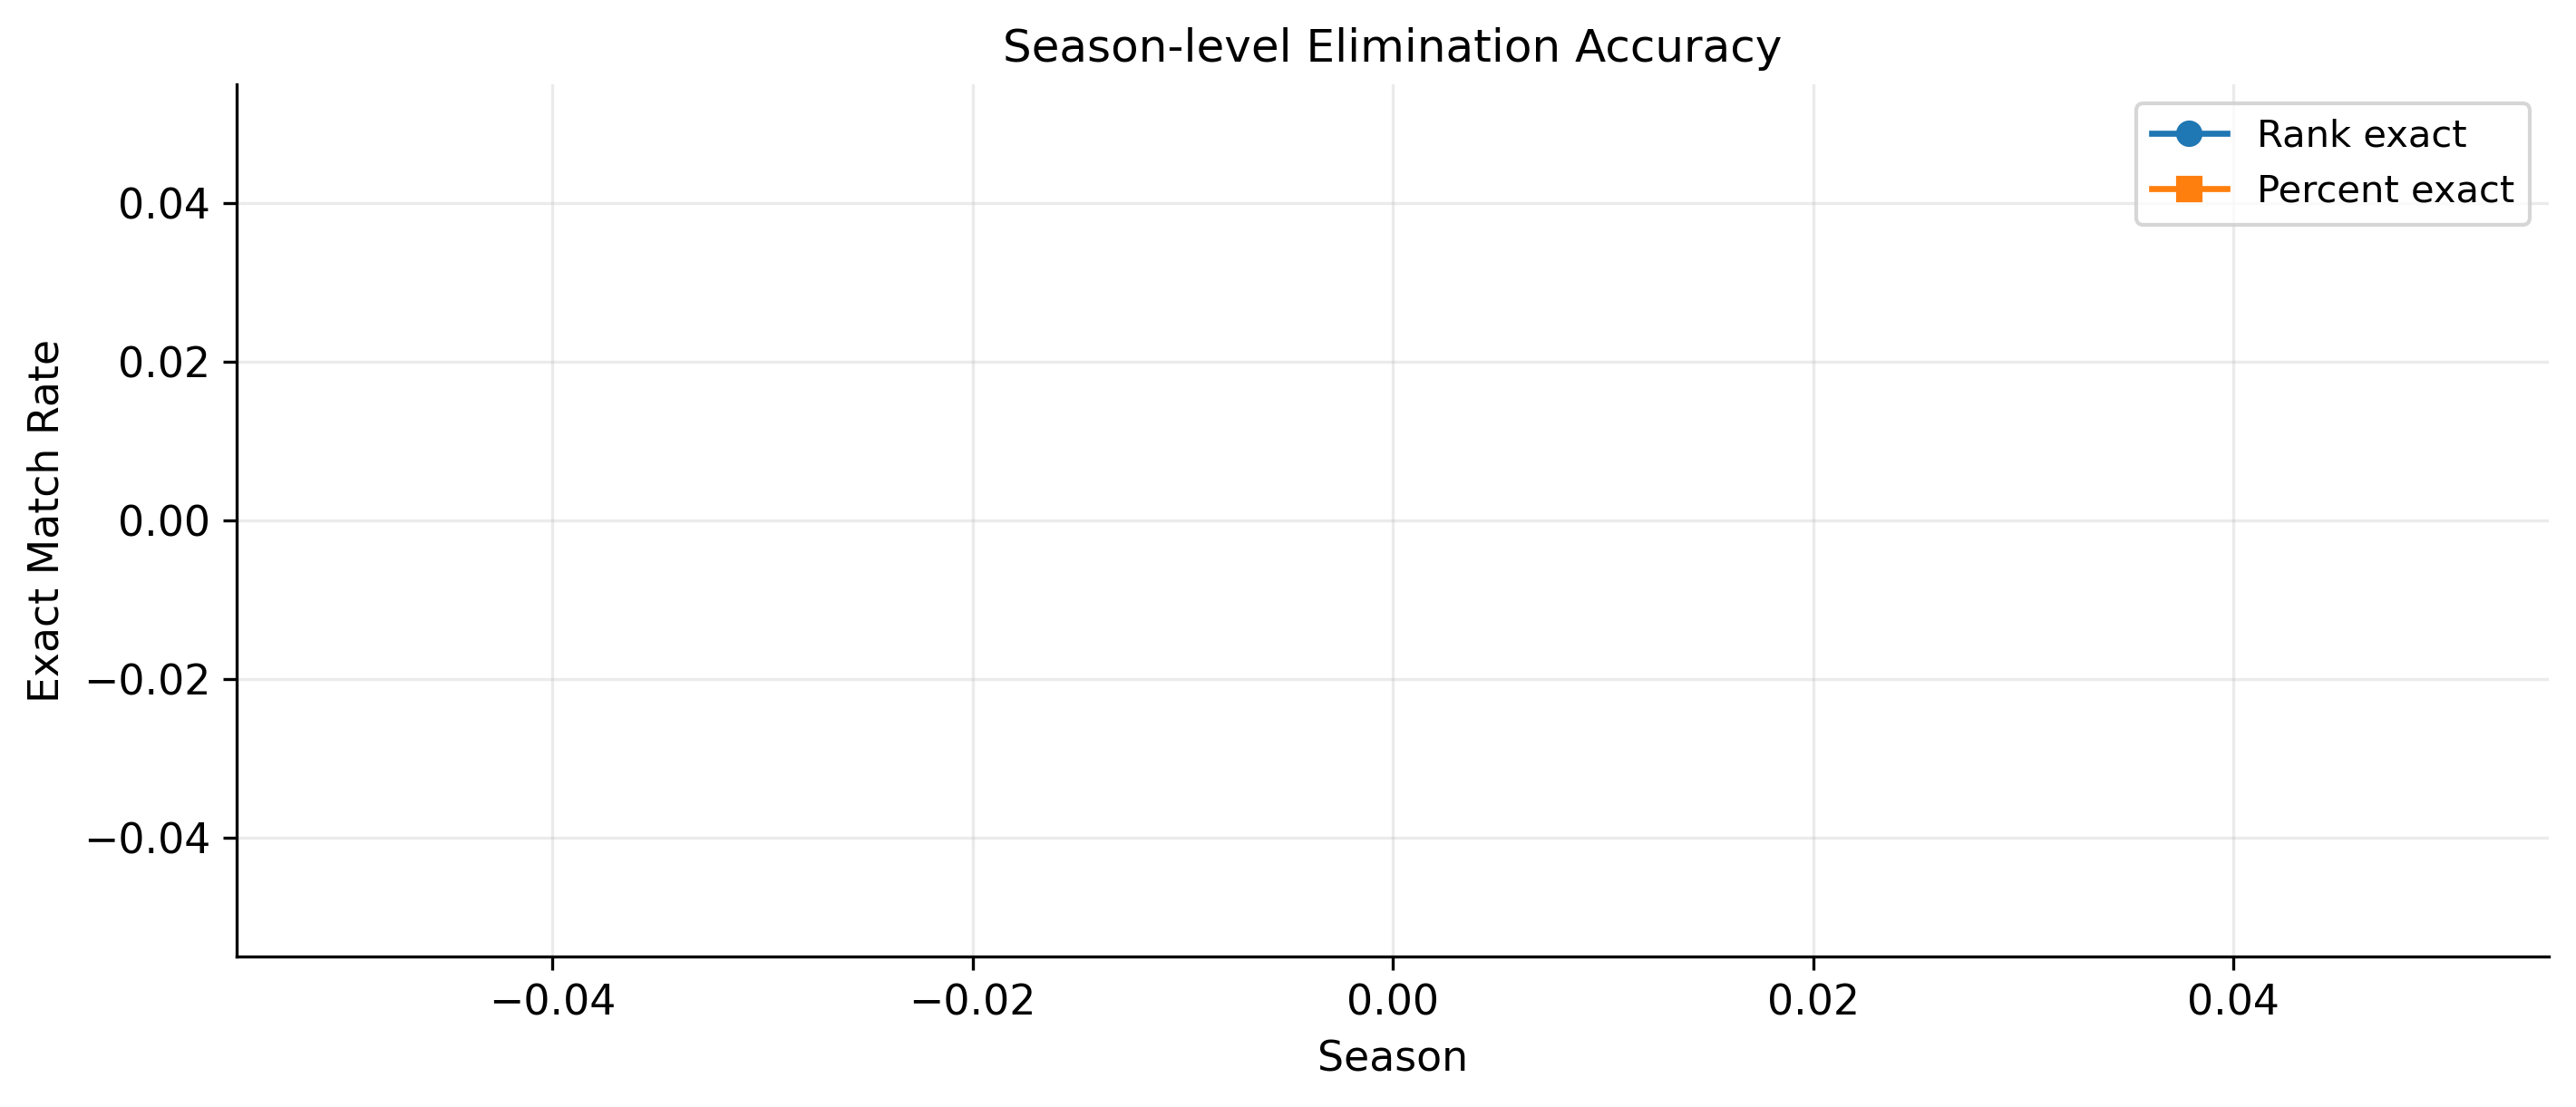

In [36]:
# -----------------------------
# 2.3-5 可视化：赛季层“准确率 vs 偏向性 vs 争议率”
# -----------------------------
plt.figure(figsize=(9.6, 4.2), dpi=300)
plt.plot(dashboard["season"], dashboard["rank_exact_elim"], marker="o", label="Rank exact")
plt.plot(dashboard["season"], dashboard["pct_exact_elim"], marker="s", label="Percent exact")
plt.title("Season-level Elimination Accuracy")
plt.xlabel("Season")
plt.ylabel("Exact Match Rate")
plt.legend()
plt.tight_layout()
plt.show()

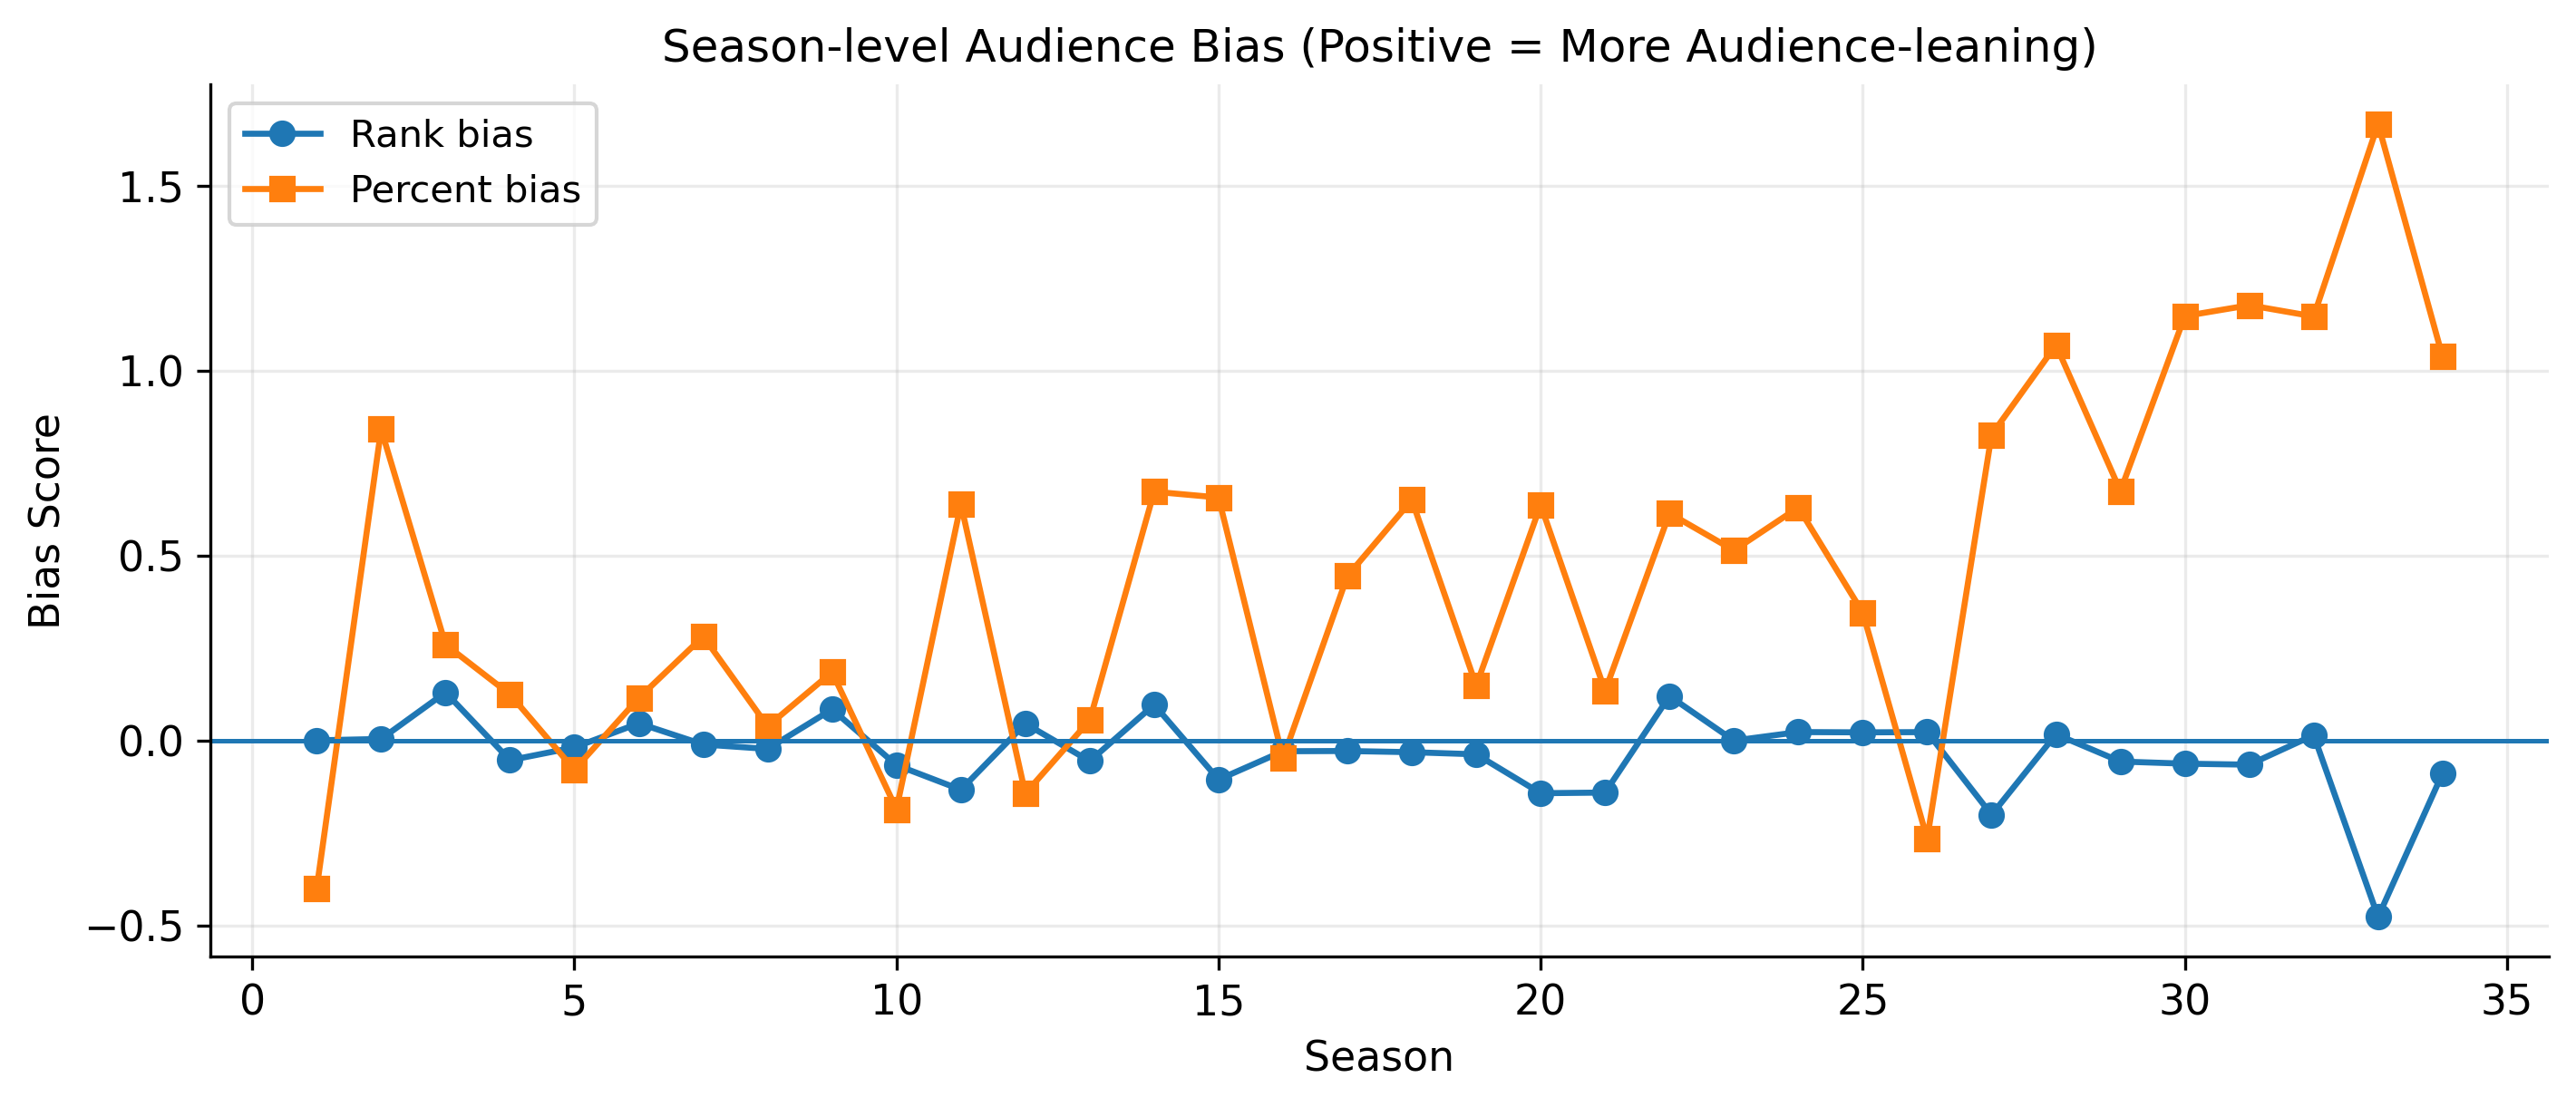

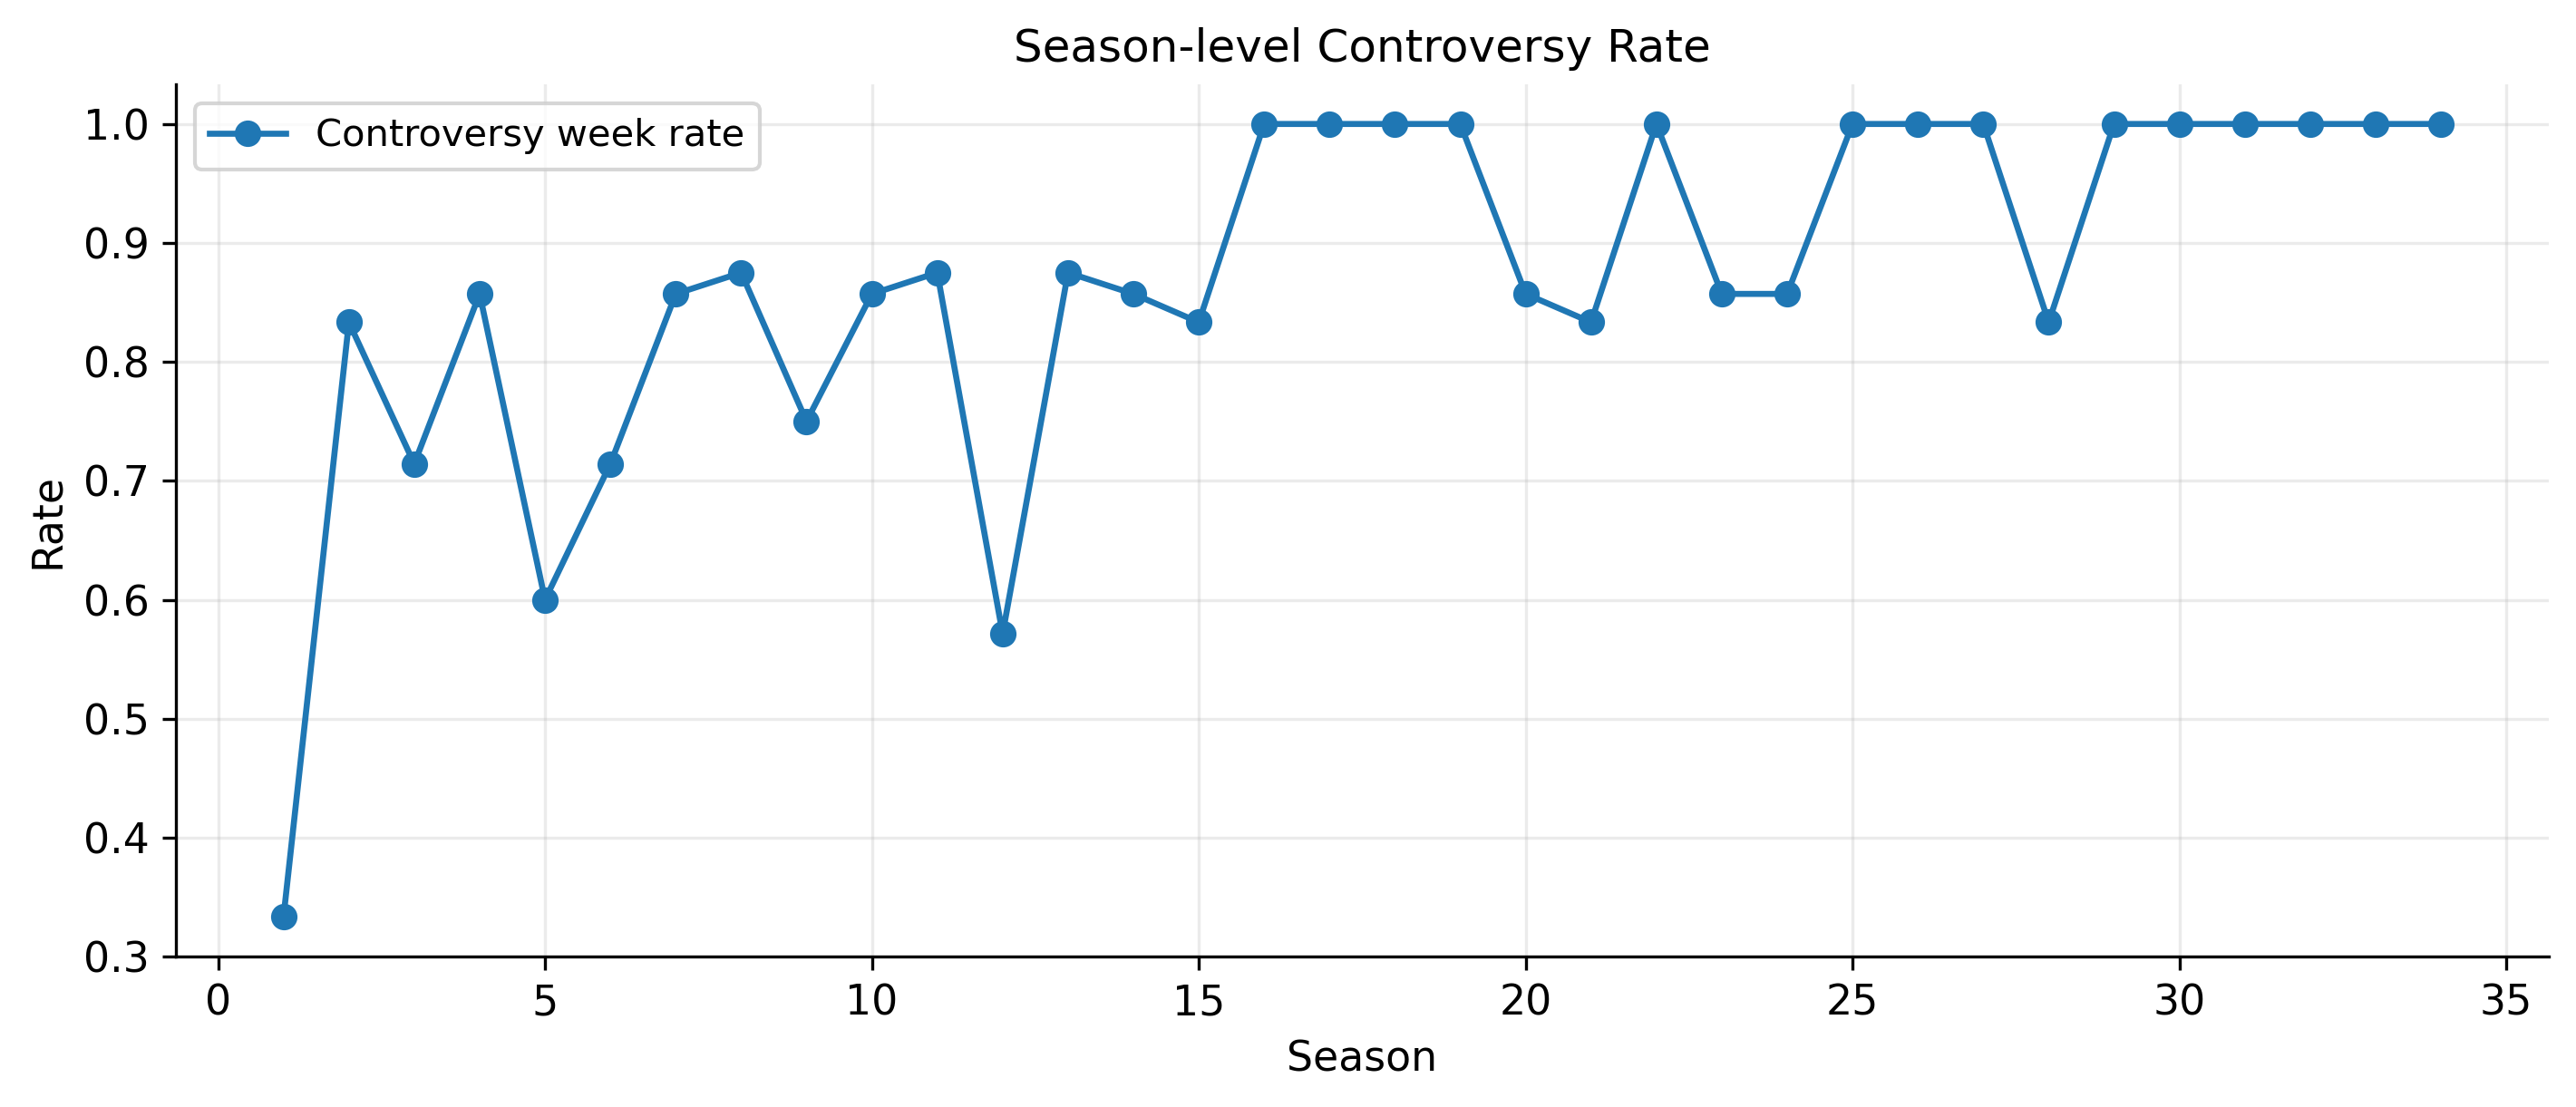

In [37]:
plt.figure(figsize=(9.6, 4.2), dpi=300)
plt.plot(dashboard["season"], dashboard["bias_rank_mean"], marker="o", label="Rank bias")
plt.plot(dashboard["season"], dashboard["bias_pct_mean"], marker="s", label="Percent bias")
plt.axhline(0, linewidth=1.2)
plt.title("Season-level Audience Bias (Positive = More Audience-leaning)")
plt.xlabel("Season")
plt.ylabel("Bias Score")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9.6, 4.2), dpi=300)
plt.plot(dashboard["season"], dashboard["contro_week_rate"], marker="o", label="Controversy week rate")
plt.title("Season-level Controversy Rate")
plt.xlabel("Season")
plt.ylabel("Rate")
plt.legend()
plt.tight_layout()
plt.show()


In [38]:

import os
import pandas as pd

DATA_DIR = "./data"
os.makedirs(DATA_DIR, exist_ok=True)

print("\n【保存汇总】开始把问题2（1/2/3小问）关键输出统一落盘到 ./data ...")

def _save_csv(df: pd.DataFrame, fname: str):
    """简化保存：统一utf-8-sig，便于Excel直接打开"""
    path = os.path.join(DATA_DIR, fname)
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print(f"  已保存：{fname}  shape={df.shape}")

# -----------------------------
# Q2-1：跨季对比（周级、季级、差异周）
# -----------------------------
_save_csv(q2_wk, "Q2_part1_week_level_rank_vs_percent_comparison.csv")
_save_csv(season_agg, "Q2_part1_season_level_rank_vs_percent_summary.csv")
_save_csv(diff_weeks, "Q2_part1_diff_weeks_elimination_only.csv")

# -----------------------------
# Q2-2：争议识别与四个示例/自动争议分析汇总
# -----------------------------
_save_csv(wk_contro, "Q2_part2_week_level_controversy_summary.csv")
_save_csv(season_contro_agg, "Q2_part2_season_level_controversy_summary.csv")
_save_csv(contro_report_df, "Q2_part2_controversy_reports_summary.csv")

# -----------------------------
# Q2-3：推荐与仪表盘
# -----------------------------
_save_csv(dashboard, "Q2_part3_decision_dashboard_by_season.csv")
_save_csv(pd.DataFrame([overall]), "Q2_part3_overall_key_metrics.csv")





【保存汇总】开始把问题2（1/2/3小问）关键输出统一落盘到 ./data ...
  已保存：Q2_part1_week_level_rank_vs_percent_comparison.csv  shape=(222, 16)
  已保存：Q2_part1_season_level_rank_vs_percent_summary.csv  shape=(34, 10)
  已保存：Q2_part1_diff_weeks_elimination_only.csv  shape=(0, 16)
  已保存：Q2_part2_week_level_controversy_summary.csv  shape=(222, 7)
  已保存：Q2_part2_season_level_controversy_summary.csv  shape=(34, 7)
  已保存：Q2_part2_controversy_reports_summary.csv  shape=(4, 20)
  已保存：Q2_part3_decision_dashboard_by_season.csv  shape=(34, 16)
  已保存：Q2_part3_overall_key_metrics.csv  shape=(1, 13)
